# Compare YOLO26-seg Fine-tuning Versions on ISIC 2018 Task 1

Notebook unificado de comparação entre múltiplas versões de fine-tuning do
**YOLO26-seg** no **ISIC 2018 Task 1** (segmentação de lesões de pele).

## Conteúdo

1. **Setup** — paths, paleta categórica acessível (Okabe-Ito-like), helpers
2. **Carga de dados** — `results.csv` + `args.yaml` (extrai LR, optimizer, AMP, batch)
3. **Resumo executivo** — tabela ranqueada com melhor versão por modelo
4. **Performance principal** — barras de Mask/BBox mAP com Y-axis cropado
5. **Métricas operacionais** — Precision/Recall/Loss/Tempo de treino
6. **Δ entre versões** — heatmaps das diferenças par-a-par (RdBu)
7. **Robustez geométrica** — `mAP@50-95 / mAP@50` (qualidade da borda da máscara)
8. **Estabilidade** — desvio-padrão de `mAP@50-95(M)` nas últimas 10 épocas
9. **Convergência** — épocas até atingir 95% e 99% do best
10. **Curvas de treino** — `mAP@50-95(M)` suavizado, hue=versão
11. **Curvas de loss** — `train vs val seg_loss` (gap = overfit)
12. **LR efetivo** — `lr/pg0` médio por versão (explica diferenças)
13. **Pareto mAP × tempo** — scatter para escolha de modelo de produção
14. **Hiperparâmetros** — diff visual entre `args.yaml` de cada versão
15. **Conclusões** — destaques automáticos (champion, biggest gain, etc.)

## Decisões de visualização

- **Paleta**: Okabe-Ito (acessível para daltônicos, distinguível em cinza).
- **Y-axis cropado**: faixa de mAP é tipicamente 0.60-0.99; cropar deixa as
  diferenças (que estão em casa de 1-3 pts percentuais) visíveis.
- **Legendas fora dos eixos** (`bbox_to_anchor`) para não cobrir dados.
- **Anotações de valor nas barras** com `padding` proporcional ao tamanho
  do eixo.


## 1. Setup

In [57]:
import warnings
from pathlib import Path
from typing import Iterable

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display, Markdown
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

# ----- estilo global ---------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "legend.fontsize": 10,
})
sns.set_context("notebook", font_scale=1.0)

# ----- paleta versões (Okabe-Ito subset, colorblind-safe) -------------------
VERSION_PALETTE = {
    "v1": "#0072B2",  # blue
    "v2": "#E69F00",  # orange
    "v3": "#009E73",  # bluish green
    "v7": "#D55E00",  # vermillion
    "v8": "#CC79A7",  # reddish purple — HPO-tuned
}
MODEL_PALETTE = {
    "Nano":   "#56B4E9",
    "Small":  "#0072B2",
    "Medium": "#009E73",
    "Large":  "#E69F00",
    "XLarge": "#D55E00",
}
SUCCESS = "#2A9D8F"
DANGER = "#E63946"
NEUTRAL = "#6C757D"

print("Setup OK — palette:", list(VERSION_PALETTE))


Setup OK — palette: ['v1', 'v2', 'v3', 'v7', 'v8']


### 1.1 Path configuration

In [58]:
# Mude `unb_server` conforme o ambiente.
unb_server = True

if unb_server:
    BASE_DIR = Path("/home/antoniovinicius/projects/sandbox_yolo26")
else:
    BASE_DIR = Path("/home/avmoura_linux/Documents/unb/sandbox_yolo26")

# Cada versão tem um nome de pasta e um padrão de subpasta diferente.
# Adicione/remova versões aqui — todo o resto do notebook se adapta.
VERSIONS = {
    "v1": {
        "log_dir": BASE_DIR / "logs" / "train_isic_2018_task_1_v1",
        "model_dirs": {
            "Nano":   "yolo26_nano_ft_isic_2018_task_1_100",
            "Small":  "yolo26_small_ft_isic_2018_task_1_100",
            "Medium": "yolo26_medium_ft_isic_2018_task_1_100",
            "Large":  "yolo26_large_ft_isic_2018_task_1_100",
            "XLarge": "yolo26_xlarge_ft_isic_2018_task_1_100",
        },
    },
    "v2": {
        "log_dir": BASE_DIR / "logs" / "train_isic_2018_task_1_v2",
        "model_dirs": {
            "Nano":   "yolo26_nano_ft_isic_2018_task_1_100",
            "Small":  "yolo26_small_ft_isic_2018_task_1_100",
            "Medium": "yolo26_medium_ft_isic_2018_task_1_100",
            "Large":  "yolo26_large_ft_isic_2018_task_1_100",
            "XLarge": "yolo26_xlarge_ft_isic_2018_task_1_100",
        },
    },
    "v3": {
        "log_dir": BASE_DIR / "logs" / "train_isic_2018_task_1_v3",
        "model_dirs": {
            "Nano":   "yolo26_nano_ft_isic_2018",
            "Small":  "yolo26_small_ft_isic_2018",
            "Medium": "yolo26_medium_ft_isic_2018",
            "Large":  "yolo26_large_ft_isic_2018",
            "XLarge": "yolo26_xlarge_ft_isic_2018",
        },
    },
    "v7": {
        "log_dir": BASE_DIR / "logs" / "train_isic_2018_task_1_v7",
        "model_dirs": {
            "Nano":   "yolo26_nano_ft_isic_2018_v7",
            "Small":  "yolo26_small_ft_isic_2018_v7",
            "Medium": "yolo26_medium_ft_isic_2018_v7",
            "Large":  "yolo26_large_ft_isic_2018_v7",
            "XLarge": "yolo26_xlarge_ft_isic_2018_v7",
        },
    },
    # v8 — HPO-tuned (best of 30 trials × 30 ep, validado em treino full-length).
    # Roda o `train_isic_2018_task_1_v8.py --model <size>` para gerar cada uma.
    # "v8": {
    #     "log_dir": BASE_DIR / "logs" / "train_isic_2018_task_1_v8",
    #     "model_dirs": {
    #         "Nano":   "yolo26_nano_ft_isic_2018_v8",
    #         "Small":  "yolo26_small_ft_isic_2018_v8",
    #         "Medium": "yolo26_medium_ft_isic_2018_v8",
    #         "Large":  "yolo26_large_ft_isic_2018_v8",
    #         "XLarge": "yolo26_xlarge_ft_isic_2018_v8",
    #     },
    # },
}

MODEL_ORDER = ["Nano", "Small", "Medium", "Large", "XLarge"]
VERSION_ORDER = list(VERSIONS.keys())

# Confere se as pastas existem
for v, cfg in VERSIONS.items():
    for m, d in cfg["model_dirs"].items():
        p = cfg["log_dir"] / d
        if not p.exists():
            print(f"  [missing] {v}/{m}: {p}")
print(f"\nVersões: {VERSION_ORDER}  |  Modelos: {MODEL_ORDER}")



Versões: ['v1', 'v2', 'v3', 'v7']  |  Modelos: ['Nano', 'Small', 'Medium', 'Large', 'XLarge']


## 2. Helpers

In [59]:
def smooth(x: np.ndarray, window: int = 5) -> np.ndarray:
    """Centered moving average (NaN-safe)."""
    s = pd.Series(x).rolling(window=window, center=True, min_periods=1).mean()
    return s.to_numpy()


def add_value_labels(ax, fmt: str = "{:.3f}", padding: float = 0.005, fontsize: int = 9) -> None:
    """Annotate bars with their height. Padding is proportional to ymax."""
    ymin, ymax = ax.get_ylim()
    pad = (ymax - ymin) * padding
    for p in ax.patches:
        h = p.get_height()
        if not np.isfinite(h):
            continue
        ax.annotate(
            fmt.format(h),
            (p.get_x() + p.get_width() / 2.0, h + pad),
            ha="center", va="bottom", fontsize=fontsize, color="#333",
        )


def crop_y(ax, values: Iterable[float], pad_below: float = 0.02, pad_above: float = 0.04,
           floor: float | None = None, ceil: float | None = None) -> None:
    """Crop y-axis to the signal region (mAP rarely uses 0-1 fully)."""
    arr = np.asarray([v for v in values if np.isfinite(v)])
    if arr.size == 0:
        return
    lo, hi = float(arr.min()) - pad_below, float(arr.max()) + pad_above
    if floor is not None:
        lo = max(lo, floor)
    if ceil is not None:
        hi = min(hi, ceil)
    ax.set_ylim(lo, hi)


def epochs_to_threshold(df: pd.DataFrame, col: str, frac: float = 0.95) -> int | float:
    """Number of epochs to reach `frac * best(col)` for the first time."""
    if col not in df or df[col].dropna().empty:
        return np.nan
    target = df[col].max() * frac
    hit = df.loc[df[col] >= target, "epoch"]
    if hit.empty:
        return np.nan
    return int(hit.iloc[0])


def stability(df: pd.DataFrame, col: str, last_n: int = 10) -> float:
    """Std of the last N epochs (lower = more stable)."""
    if col not in df:
        return np.nan
    s = df[col].dropna().tail(last_n)
    return float(s.std()) if not s.empty else np.nan


def overfit_gap(df: pd.DataFrame, best_idx: int, train_col: str, val_col: str) -> float:
    """val-train at best epoch (positive = overfit)."""
    try:
        return float(df.loc[best_idx, val_col] - df.loc[best_idx, train_col])
    except (KeyError, IndexError):
        return np.nan


print("Helpers ready")


Helpers ready


## 3. Carga de dados (`results.csv` + `args.yaml`)

In [60]:
def extract_summary(version: str, model_name: str, results_dir: Path) -> dict | None:
    """Extract all summary metrics from a single training run."""
    rcsv = results_dir / "results.csv"
    if not rcsv.exists():
        return None
    df = pd.read_csv(rcsv)
    df.columns = [c.strip() for c in df.columns]

    if "metrics/mAP50-95(M)" not in df:
        return None

    best_idx = df["metrics/mAP50-95(M)"].idxmax()
    best = df.loc[best_idx]

    args_path = results_dir / "args.yaml"
    args = {}
    if args_path.exists():
        try:
            args = yaml.safe_load(args_path.read_text()) or {}
        except yaml.YAMLError:
            args = {}

    # LR diagnostics
    if "lr/pg0" in df:
        lr = df["lr/pg0"]
        n = len(lr)
        lr_start = float(lr.iloc[: max(1, n // 10)].mean())
        lr_mid = float(lr.iloc[n // 3: 2 * n // 3].mean())
        lr_end = float(lr.iloc[-max(1, n // 10):].mean())
    else:
        lr_start = lr_mid = lr_end = np.nan

    return {
        "Version": version,
        "Model": model_name,
        "Run dir": results_dir.name,
        # best metrics
        "Mask mAP@50": float(best.get("metrics/mAP50(M)", np.nan)),
        "Mask mAP@50-95": float(best.get("metrics/mAP50-95(M)", np.nan)),
        "BBox mAP@50": float(best.get("metrics/mAP50(B)", np.nan)),
        "BBox mAP@50-95": float(best.get("metrics/mAP50-95(B)", np.nan)),
        "Mask Precision": float(best.get("metrics/precision(M)", np.nan)),
        "Mask Recall": float(best.get("metrics/recall(M)", np.nan)),
        # losses
        "Val seg_loss": float(best.get("val/seg_loss", np.nan)),
        "Train seg_loss": float(best.get("train/seg_loss", np.nan)),
        "Overfit gap (seg)": overfit_gap(df, best_idx, "train/seg_loss", "val/seg_loss"),
        # training dynamics
        "Best epoch": int(best.get("epoch", best_idx)),
        "Total epochs": int(df["epoch"].max()),
        "Train time (min)": float(df["time"].iloc[-1] / 60.0) if "time" in df else np.nan,
        # convergence + stability
        "Eps to 95% best": epochs_to_threshold(df, "metrics/mAP50-95(M)", 0.95),
        "Eps to 99% best": epochs_to_threshold(df, "metrics/mAP50-95(M)", 0.99),
        "Stability (std last10)": stability(df, "metrics/mAP50-95(M)", last_n=10),
        # LR effective
        "lr/pg0 start": lr_start,
        "lr/pg0 mid": lr_mid,
        "lr/pg0 end": lr_end,
        # hyperparameters of interest (from args.yaml)
        "optimizer": args.get("optimizer", "?"),
        "lr0": args.get("lr0", np.nan),
        "amp": args.get("amp", "?"),
        "batch": args.get("batch", "?"),
        "epochs (cfg)": args.get("epochs", "?"),
        "close_mosaic": args.get("close_mosaic", "?"),
        "erasing": args.get("erasing", "?"),
        "weight_decay": args.get("weight_decay", "?"),
        "dropout": args.get("dropout", "?"),
        # full df for curves
        "_df": df,
    }


rows = []
for v in VERSION_ORDER:
    cfg = VERSIONS[v]
    for m in MODEL_ORDER:
        d = cfg["log_dir"] / cfg["model_dirs"][m]
        s = extract_summary(v, m, d)
        if s is None:
            print(f"  [skip] {v}/{m} (no results.csv)")
            continue
        rows.append(s)

df_long = pd.DataFrame(rows)
df_long["Version"] = pd.Categorical(df_long["Version"], categories=VERSION_ORDER, ordered=True)
df_long["Model"] = pd.Categorical(df_long["Model"], categories=MODEL_ORDER, ordered=True)
df_long = df_long.sort_values(["Model", "Version"]).reset_index(drop=True)

print(f"Loaded {len(df_long)} runs across {df_long['Version'].nunique()} versions × {df_long['Model'].nunique()} models")
display(df_long.drop(columns=["_df"]).head(8))


Loaded 20 runs across 4 versions × 5 models


,Version,Model,Run dir,Mask mAP@50,Mask mAP@50-95,BBox mAP@50,BBox mAP@50-95,Mask Precision,Mask Recall,Val seg_loss,...,lr/pg0 end,optimizer,lr0,amp,batch,epochs (cfg),close_mosaic,erasing,weight_decay,dropout
0,v1,Nano,yolo26_nano_ft_isic_2018_task_1_100,0.96166,0.69929,0.96374,0.64722,0.93813,0.90982,1.54284,...,0.000129,auto,0.010,True,16,100,10,0.4,0.0005,0.0
1,v2,Nano,yolo26_nano_ft_isic_2018_task_1_100,0.96408,0.72834,0.95286,0.69940,0.95865,0.92739,1.37076,...,0.001124,MuSGD,0.001,False,-1,100,10,0.4,0.0005,0.0
2,v3,Nano,yolo26_nano_ft_isic_2018,0.97447,0.71416,0.97946,0.65370,0.95772,0.93000,1.25893,...,0.000299,AdamW,0.001,True,16,150,15,0.0,0.0010,0.1
3,v7,Nano,yolo26_nano_ft_isic_2018_v7,0.95778,0.69596,0.95752,0.68925,0.90852,0.89383,1.56254,...,0.004679,MuSGD,0.002,True,32,120,15,0.0,0.0005,0.0
4,v1,Small,yolo26_small_ft_isic_2018_task_1_100,0.98759,0.71399,0.98828,0.68794,0.97878,0.97000,1.60193,...,0.000129,auto,0.010,True,16,100,10,0.4,0.0005,0.0
5,v2,Small,yolo26_small_ft_isic_2018_task_1_100,0.98308,0.73675,0.98308,0.68903,0.98716,0.95000,1.39604,...,0.000721,MuSGD,0.001,False,-1,100,10,0.4,0.0005,0.0
6,v3,Small,yolo26_small_ft_isic_2018,0.98507,0.70991,0.97376,0.67109,0.97805,0.95000,1.29793,...,0.000034,AdamW,0.001,True,16,150,15,0.0,0.0010,0.1
7,v7,Small,yolo26_small_ft_isic_2018_v7,0.95760,0.69640,0.97281,0.67234,0.94925,0.93527,1.57601,...,0.005237,MuSGD,0.002,True,32,120,15,0.0,0.0005,0.0


## 4. Resumo executivo

Tabela com a métrica principal (`Mask mAP@50-95`) por modelo × versão, com
**champion** marcado em verde por linha. Útil para responder rapidamente
"qual versão é melhor para cada tamanho?".


In [61]:
pivot_main = df_long.pivot(index="Model", columns="Version", values="Mask mAP@50-95")
pivot_main = pivot_main[VERSION_ORDER].reindex(MODEL_ORDER)


def highlight_max_row(s: pd.Series):
    is_max = s == s.max()
    return [
        f"background-color: {SUCCESS}; color: white; font-weight: 600" if v else ""
        for v in is_max
    ]


display(Markdown("### 4.1 Champion por modelo (Mask mAP@50-95)"))
display(
    pivot_main.style
    .apply(highlight_max_row, axis=1)
    .format("{:.4f}")
    .set_caption("Verde = melhor versão para o modelo")
)

champion_df = pd.DataFrame({
    "Model": MODEL_ORDER,
    "Best version": [pivot_main.loc[m].idxmax() for m in MODEL_ORDER],
    "Best mAP@50-95": [pivot_main.loc[m].max() for m in MODEL_ORDER],
    "Worst version": [pivot_main.loc[m].idxmin() for m in MODEL_ORDER],
    "Spread (best-worst)": [pivot_main.loc[m].max() - pivot_main.loc[m].min() for m in MODEL_ORDER],
})

display(Markdown("### 4.2 Spread por modelo (sensibilidade a hiperparâmetros)"))
display(champion_df.style.format({"Best mAP@50-95": "{:.4f}", "Spread (best-worst)": "{:+.4f}"}))


### 4.1 Champion por modelo (Mask mAP@50-95)

Version,v1,v2,v3,v7
Model,,,,
Nano,0.6993,0.7283,0.7142,0.6960
Small,0.7140,0.7368,0.7099,0.6964
Medium,0.7275,0.6788,0.7061,0.7097
Large,0.7003,0.7237,0.7098,0.7227
XLarge,0.6751,0.7043,0.6915,0.7090


### 4.2 Spread por modelo (sensibilidade a hiperparâmetros)

,Model,Best version,Best mAP@50-95,Worst version,Spread (best-worst)
0,Nano,v2,0.7283,v7,+0.0324
1,Small,v2,0.7368,v7,+0.0403
2,Medium,v1,0.7275,v2,+0.0487
3,Large,v2,0.7237,v1,+0.0234
4,XLarge,v7,0.7090,v1,+0.0340


## 5. Performance principal

Barras agrupadas por modelo (eixo-x), uma cor por versão. Y-axis **cropado**
para a faixa de sinal — diferenças de 1-3 pontos percentuais ficam visíveis.


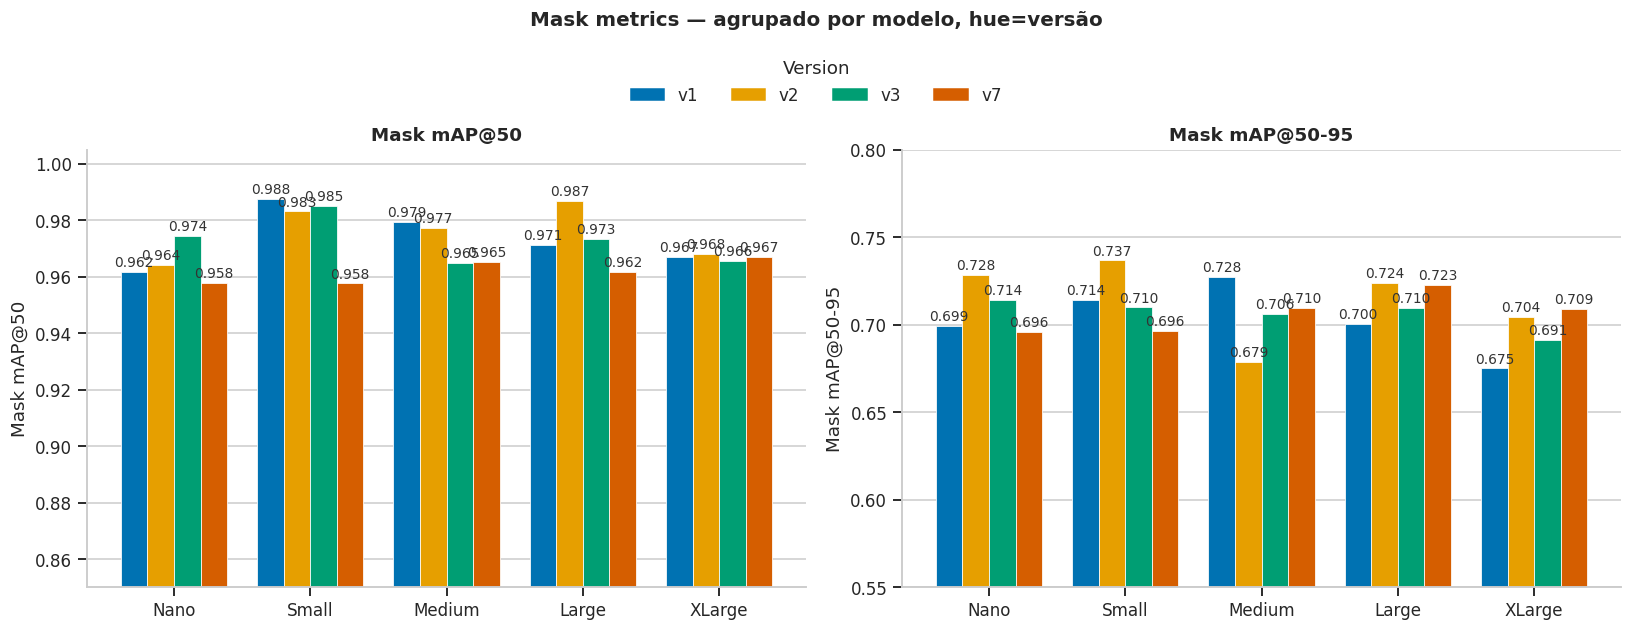

In [62]:
def grouped_bar(ax, data: pd.DataFrame, value_col: str, title: str,
                ylim: tuple[float, float] | None = None, fmt: str = "{:.3f}") -> None:
    pivot = data.pivot(index="Model", columns="Version", values=value_col)[VERSION_ORDER].reindex(MODEL_ORDER)
    pivot.plot(
        kind="bar", ax=ax, width=0.78,
        color=[VERSION_PALETTE[v] for v in VERSION_ORDER],
        edgecolor="white", linewidth=0.5,
    )
    ax.set_title(title)
    ax.set_ylabel(value_col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend_.remove()
    if ylim:
        ax.set_ylim(*ylim)
    add_value_labels(ax, fmt=fmt)
    ax.grid(axis="x", visible=False)


# ---- Mask -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
grouped_bar(axes[0], df_long, "Mask mAP@50",    "Mask mAP@50",    ylim=(0.85, 1.005))
grouped_bar(axes[1], df_long, "Mask mAP@50-95", "Mask mAP@50-95", ylim=(0.55, 0.80))

handles = [Patch(color=VERSION_PALETTE[v], label=v) for v in VERSION_ORDER]
fig.legend(handles=handles, title="Version", loc="upper center",
           bbox_to_anchor=(0.5, 1.04), ncol=len(VERSION_ORDER))
fig.suptitle("Mask metrics — agrupado por modelo, hue=versão", y=1.10, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


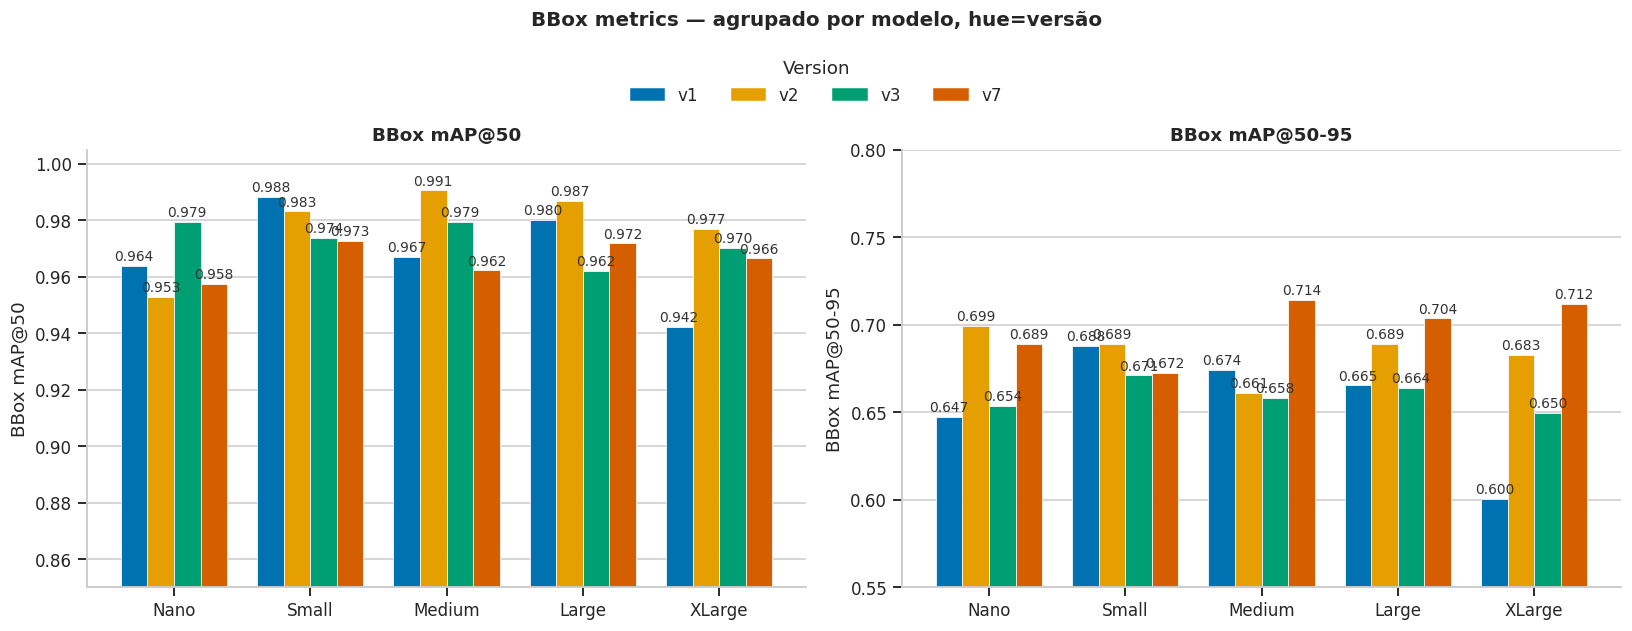

In [63]:
# ---- BBox -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
grouped_bar(axes[0], df_long, "BBox mAP@50",    "BBox mAP@50",    ylim=(0.85, 1.005))
grouped_bar(axes[1], df_long, "BBox mAP@50-95", "BBox mAP@50-95", ylim=(0.55, 0.80))

handles = [Patch(color=VERSION_PALETTE[v], label=v) for v in VERSION_ORDER]
fig.legend(handles=handles, title="Version", loc="upper center",
           bbox_to_anchor=(0.5, 1.04), ncol=len(VERSION_ORDER))
fig.suptitle("BBox metrics — agrupado por modelo, hue=versão", y=1.10, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Métricas operacionais

P/R, perda em validação no best epoch e tempo total de treino.


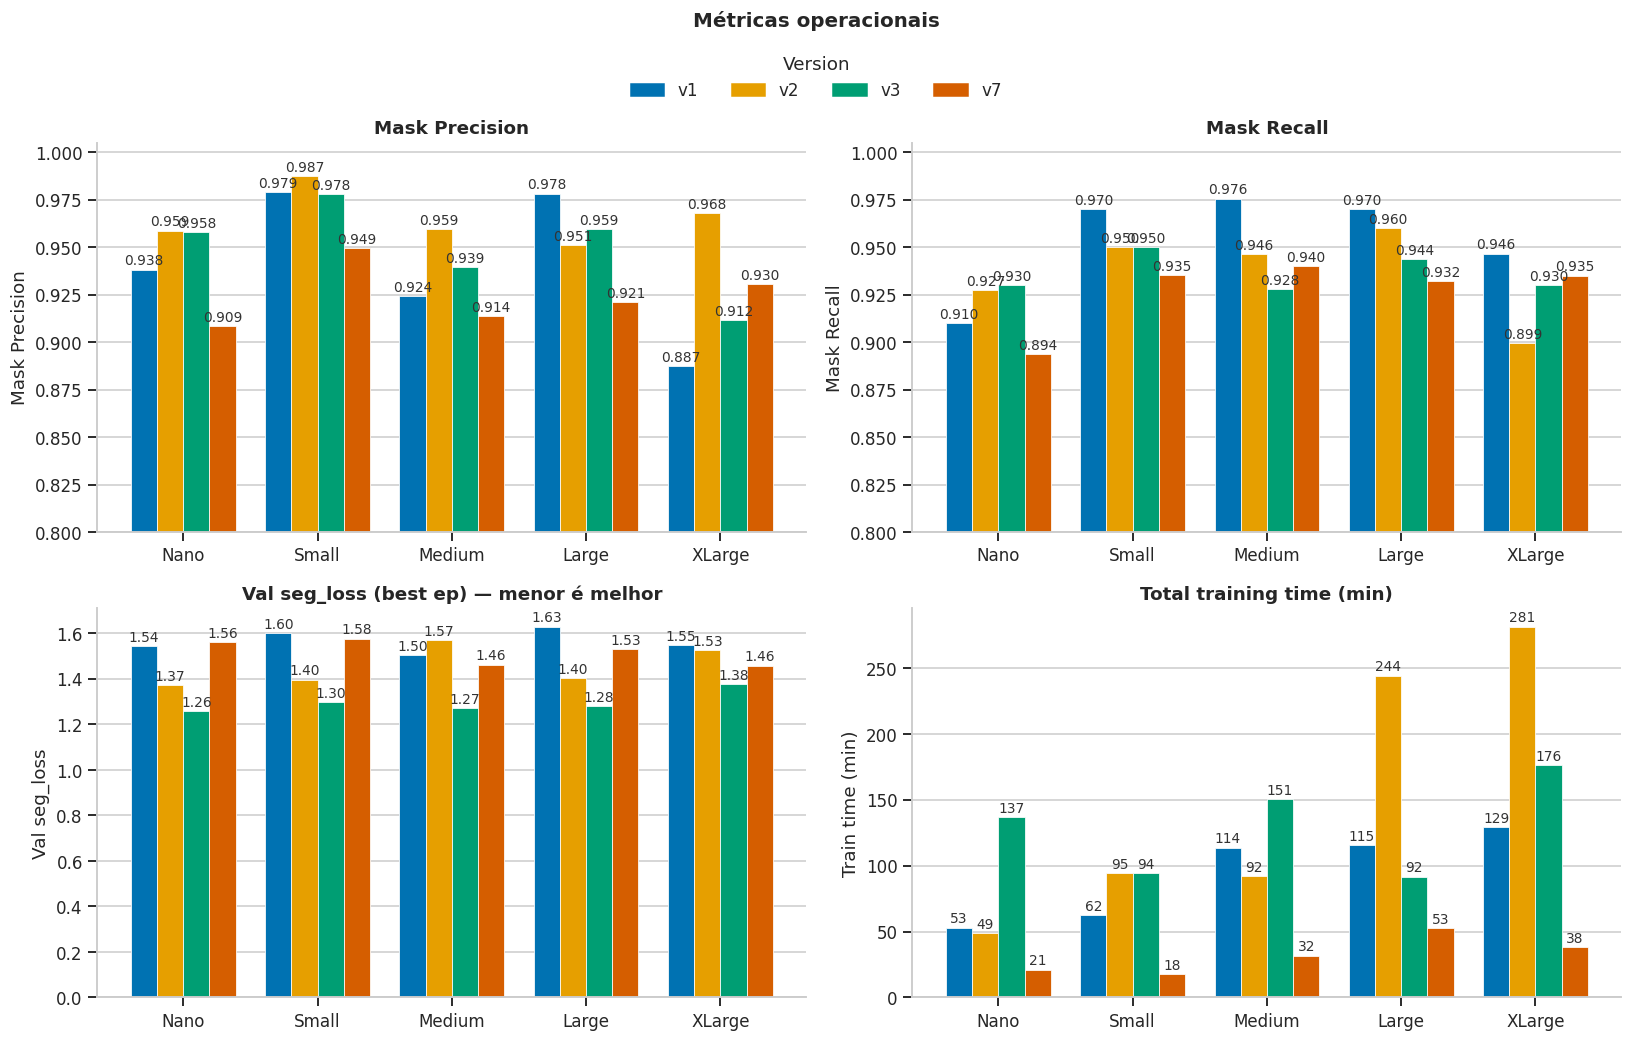

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
grouped_bar(axes[0, 0], df_long, "Mask Precision", "Mask Precision", ylim=(0.80, 1.005))
grouped_bar(axes[0, 1], df_long, "Mask Recall",    "Mask Recall",    ylim=(0.80, 1.005))
grouped_bar(axes[1, 0], df_long, "Val seg_loss",   "Val seg_loss (best ep) — menor é melhor", fmt="{:.2f}")
grouped_bar(axes[1, 1], df_long, "Train time (min)", "Total training time (min)", fmt="{:.0f}")

handles = [Patch(color=VERSION_PALETTE[v], label=v) for v in VERSION_ORDER]
fig.legend(handles=handles, title="Version", loc="upper center",
           bbox_to_anchor=(0.5, 1.02), ncol=len(VERSION_ORDER))
fig.suptitle("Métricas operacionais", y=1.05, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Δ entre versões — heatmaps

Cada heatmap mostra `mAP@50-95(M) (col) − mAP@50-95(M) (linha de referência)`.
Vermelho = a versão da coluna **piorou** vs a linha; verde = **melhorou**.


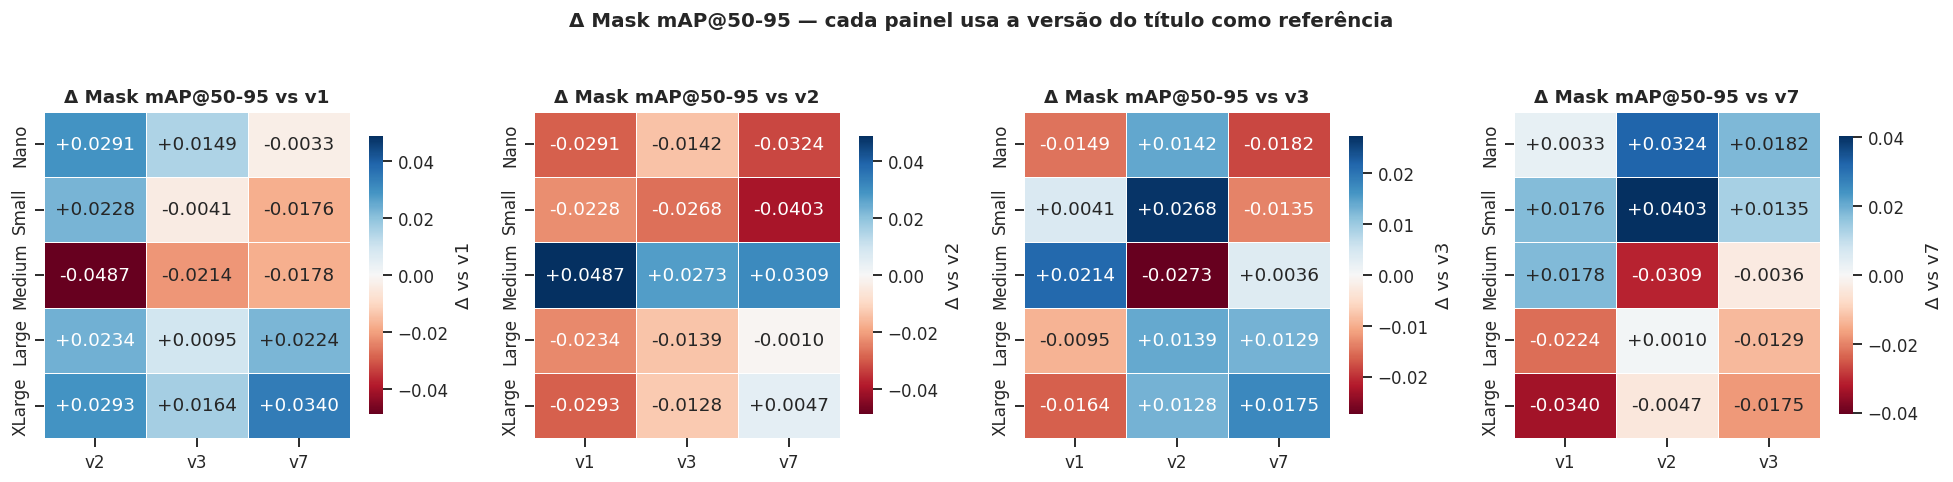

In [65]:
def delta_heatmap(ax, ref: str, data_pivot: pd.DataFrame) -> None:
    other = [v for v in VERSION_ORDER if v != ref]
    delta = data_pivot[other].subtract(data_pivot[ref], axis=0)
    vmax = max(abs(delta.min().min()), abs(delta.max().max())) or 0.001
    sns.heatmap(
        delta, annot=True, fmt="+.4f",
        cmap="RdBu", center=0, vmin=-vmax, vmax=vmax,
        cbar_kws={"label": f"Δ vs {ref}", "shrink": 0.85},
        linewidths=0.5, linecolor="white", ax=ax,
    )
    ax.set_title(f"Δ Mask mAP@50-95 vs {ref}")
    ax.set_xlabel("")
    ax.set_ylabel("")


fig, axes = plt.subplots(1, len(VERSION_ORDER), figsize=(4.5 * len(VERSION_ORDER), 4.2))
if len(VERSION_ORDER) == 1:
    axes = [axes]
for ax, ref in zip(axes, VERSION_ORDER):
    delta_heatmap(ax, ref, pivot_main)
fig.suptitle("Δ Mask mAP@50-95 — cada painel usa a versão do título como referência",
             y=1.04, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 8. Robustez geométrica — `mAP@50-95 / mAP@50`

`mAP@50` aceita IoU ≥ 0.5 (boa localização aproximada). `mAP@50-95` requer
IoU alto consistentemente. **A razão mede o quão bem a borda da máscara
preserva sua qualidade quando o critério aperta** — proxy para qualidade
da segmentação fina.


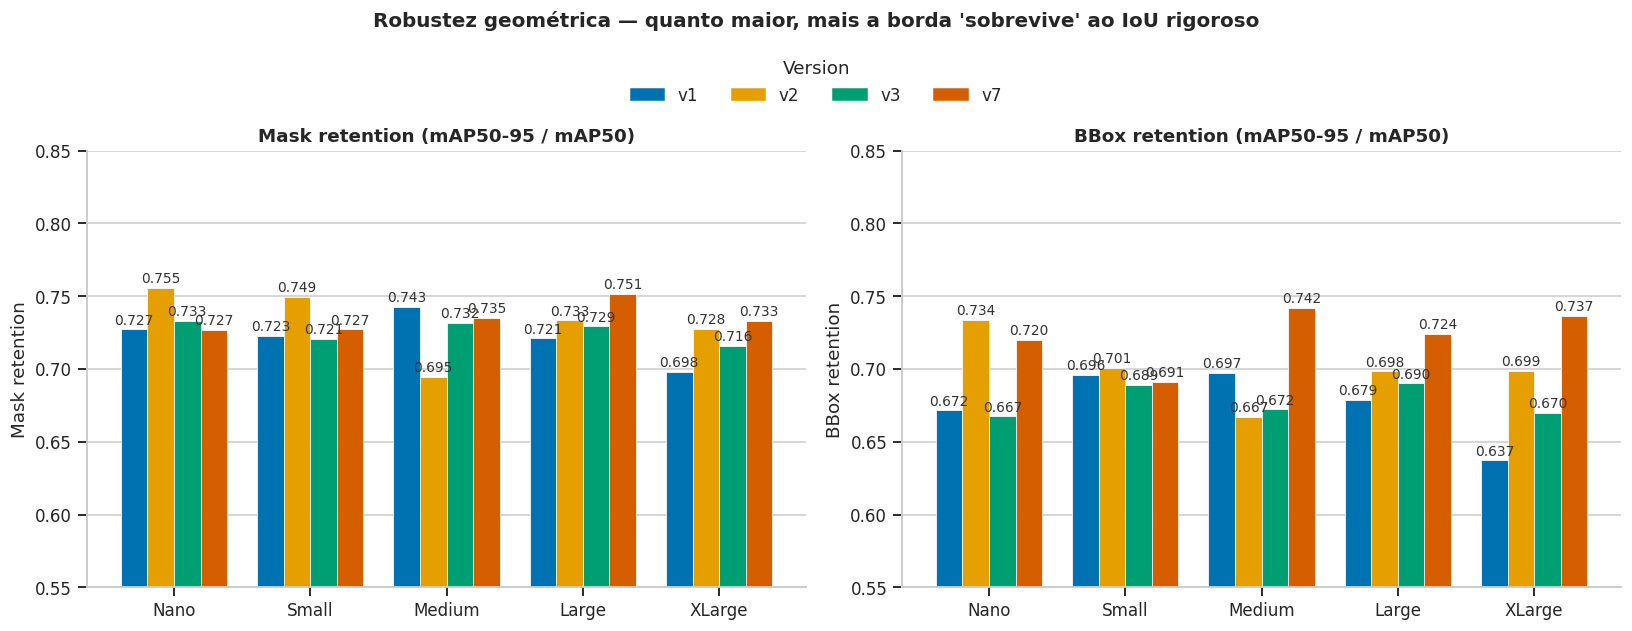

In [66]:
df_long["Mask retention"] = df_long["Mask mAP@50-95"] / df_long["Mask mAP@50"]
df_long["BBox retention"] = df_long["BBox mAP@50-95"] / df_long["BBox mAP@50"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
grouped_bar(axes[0], df_long, "Mask retention", "Mask retention (mAP50-95 / mAP50)", ylim=(0.55, 0.85))
grouped_bar(axes[1], df_long, "BBox retention", "BBox retention (mAP50-95 / mAP50)", ylim=(0.55, 0.85))

handles = [Patch(color=VERSION_PALETTE[v], label=v) for v in VERSION_ORDER]
fig.legend(handles=handles, title="Version", loc="upper center",
           bbox_to_anchor=(0.5, 1.04), ncol=len(VERSION_ORDER))
fig.suptitle("Robustez geométrica — quanto maior, mais a borda 'sobrevive' ao IoU rigoroso",
             y=1.10, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 9. Estabilidade do treino

Desvio-padrão de `mAP@50-95(M)` nas **últimas 10 épocas**. Valores baixos
indicam treino estável (modelo já convergiu). Valores altos indicam que
o run ainda está oscilando — a métrica final pode ser sorte.


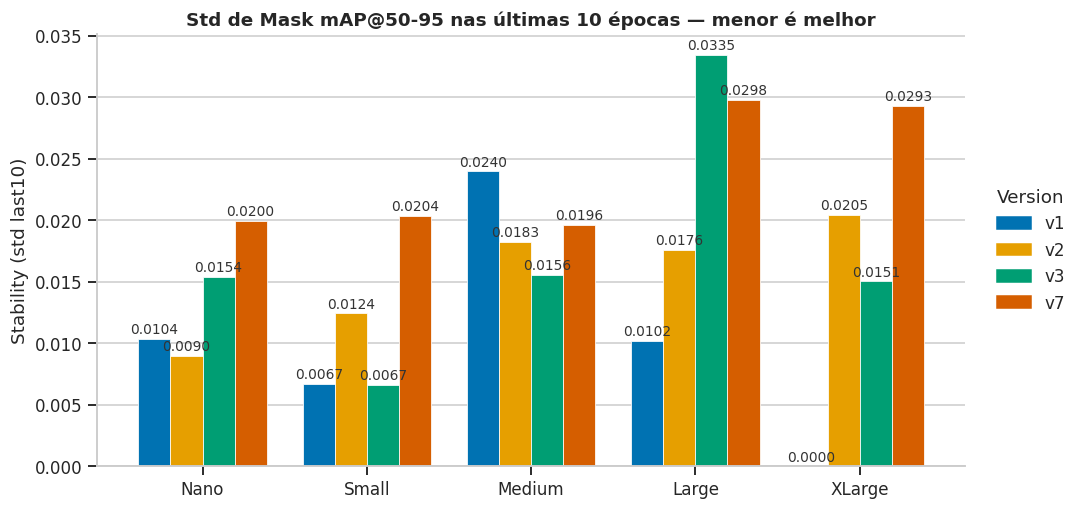

In [67]:
fig, ax = plt.subplots(figsize=(10, 4.8))
grouped_bar(ax, df_long, "Stability (std last10)",
            "Std de Mask mAP@50-95 nas últimas 10 épocas — menor é melhor", fmt="{:.4f}")

handles = [Patch(color=VERSION_PALETTE[v], label=v) for v in VERSION_ORDER]
ax.legend(handles=handles, title="Version", loc="center left",
          bbox_to_anchor=(1.02, 0.5))
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()


## 10. Velocidade de convergência

Em qual época o run atingiu **95%** e **99%** do seu próprio best?
Convergência rápida + best alto = config bem balanceada.


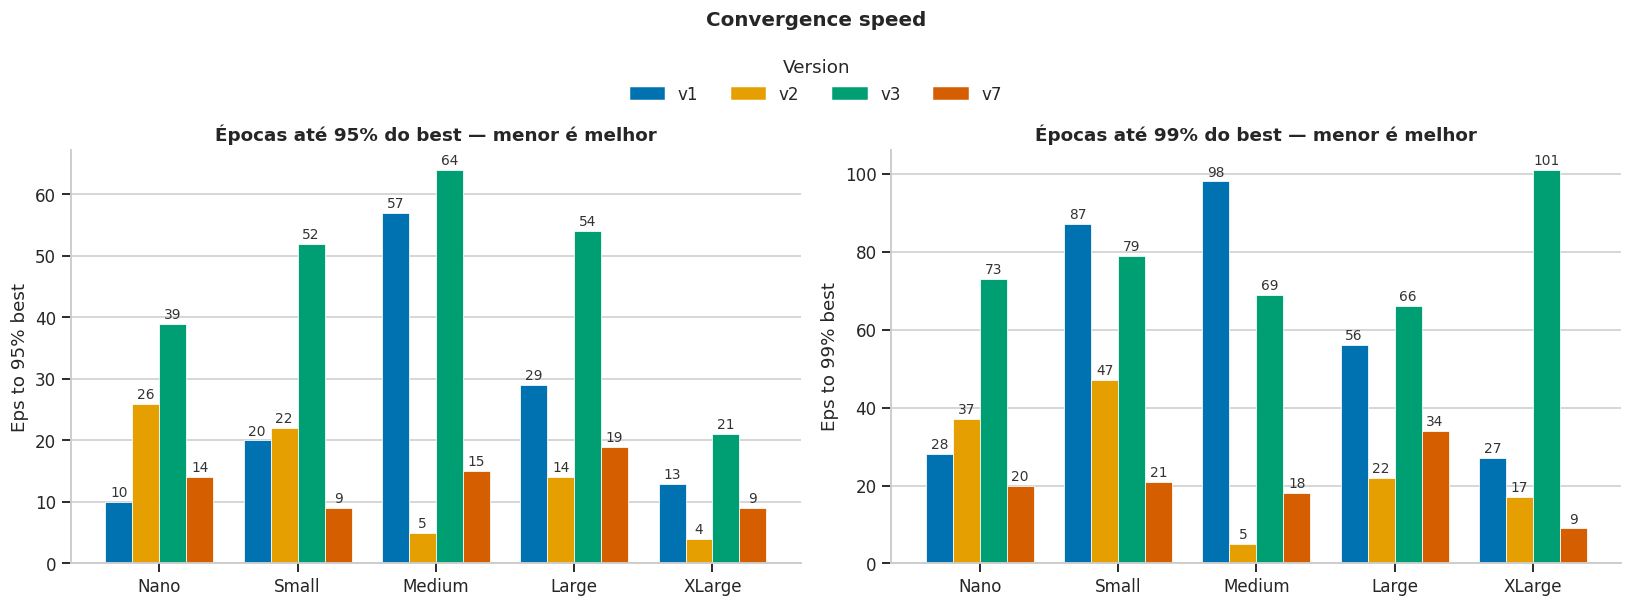

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
grouped_bar(axes[0], df_long, "Eps to 95% best", "Épocas até 95% do best — menor é melhor", fmt="{:.0f}")
grouped_bar(axes[1], df_long, "Eps to 99% best", "Épocas até 99% do best — menor é melhor", fmt="{:.0f}")

handles = [Patch(color=VERSION_PALETTE[v], label=v) for v in VERSION_ORDER]
fig.legend(handles=handles, title="Version", loc="upper center",
           bbox_to_anchor=(0.5, 1.04), ncol=len(VERSION_ORDER))
fig.suptitle("Convergence speed", y=1.10, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 11. Curvas de treino

`mAP@50-95(M)` ao longo das épocas, suavizado. Uma linha por versão, marcador
no best epoch de cada run. Useful para entender se o run **convergiu cedo**,
**oscilou**, ou **continuou subindo até o final**.


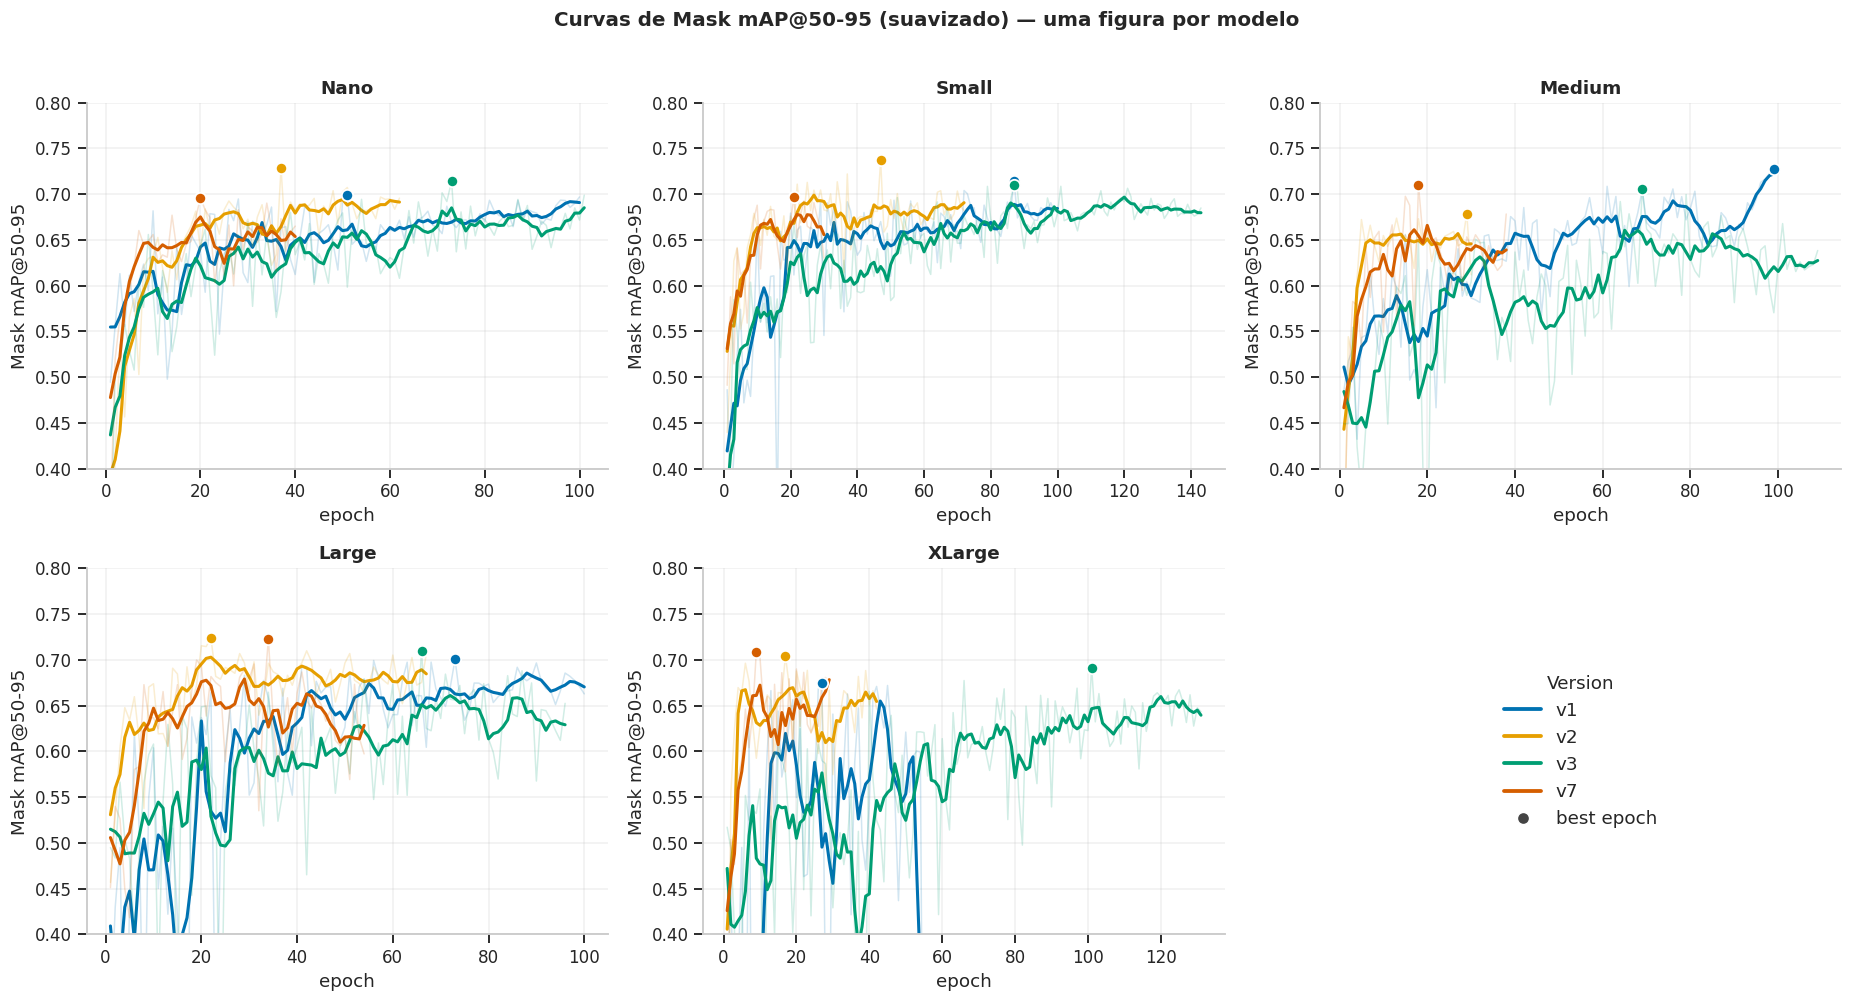

In [69]:
WINDOW = 5
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

for i, m in enumerate(MODEL_ORDER):
    ax = axes[i]
    for v in VERSION_ORDER:
        sel = df_long[(df_long["Model"] == m) & (df_long["Version"] == v)]
        if sel.empty:
            continue
        df = sel.iloc[0]["_df"]
        if "metrics/mAP50-95(M)" not in df:
            continue
        eps = df["epoch"].to_numpy()
        y = df["metrics/mAP50-95(M)"].to_numpy()
        y_smooth = smooth(y, window=WINDOW)
        c = VERSION_PALETTE[v]
        ax.plot(eps, y, color=c, alpha=0.18, lw=1)
        ax.plot(eps, y_smooth, color=c, lw=2.0, label=v)
        # marcador no best
        best_idx = int(np.argmax(y))
        ax.scatter([eps[best_idx]], [y[best_idx]], color=c, s=55, zorder=5,
                   edgecolor="white", linewidth=1.2)
    ax.set_title(f"{m}")
    ax.set_xlabel("epoch")
    ax.set_ylabel("Mask mAP@50-95")
    ax.set_ylim(0.4, 0.80)
    ax.grid(True, alpha=0.3)

# último painel: legenda
axes[-1].axis("off")
handles = [
    plt.Line2D([0], [0], color=VERSION_PALETTE[v], lw=2.5, label=v)
    for v in VERSION_ORDER
]
handles.append(plt.Line2D([0], [0], marker="o", color="#444", markersize=8, lw=0,
                          markeredgecolor="white", label="best epoch"))
axes[-1].legend(handles=handles, loc="center", title="Version", fontsize=12)

fig.suptitle("Curvas de Mask mAP@50-95 (suavizado) — uma figura por modelo",
             y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 12. Curvas de loss — `train` vs `val seg_loss`

Linha sólida = `train`, tracejada = `val`. **O gap entre as duas é o sinal
de overfitting**. Versões diferentes podem convergir para o mesmo train_loss
mas diferentes val_loss — quem tem menor val sem explodir o gap é melhor.


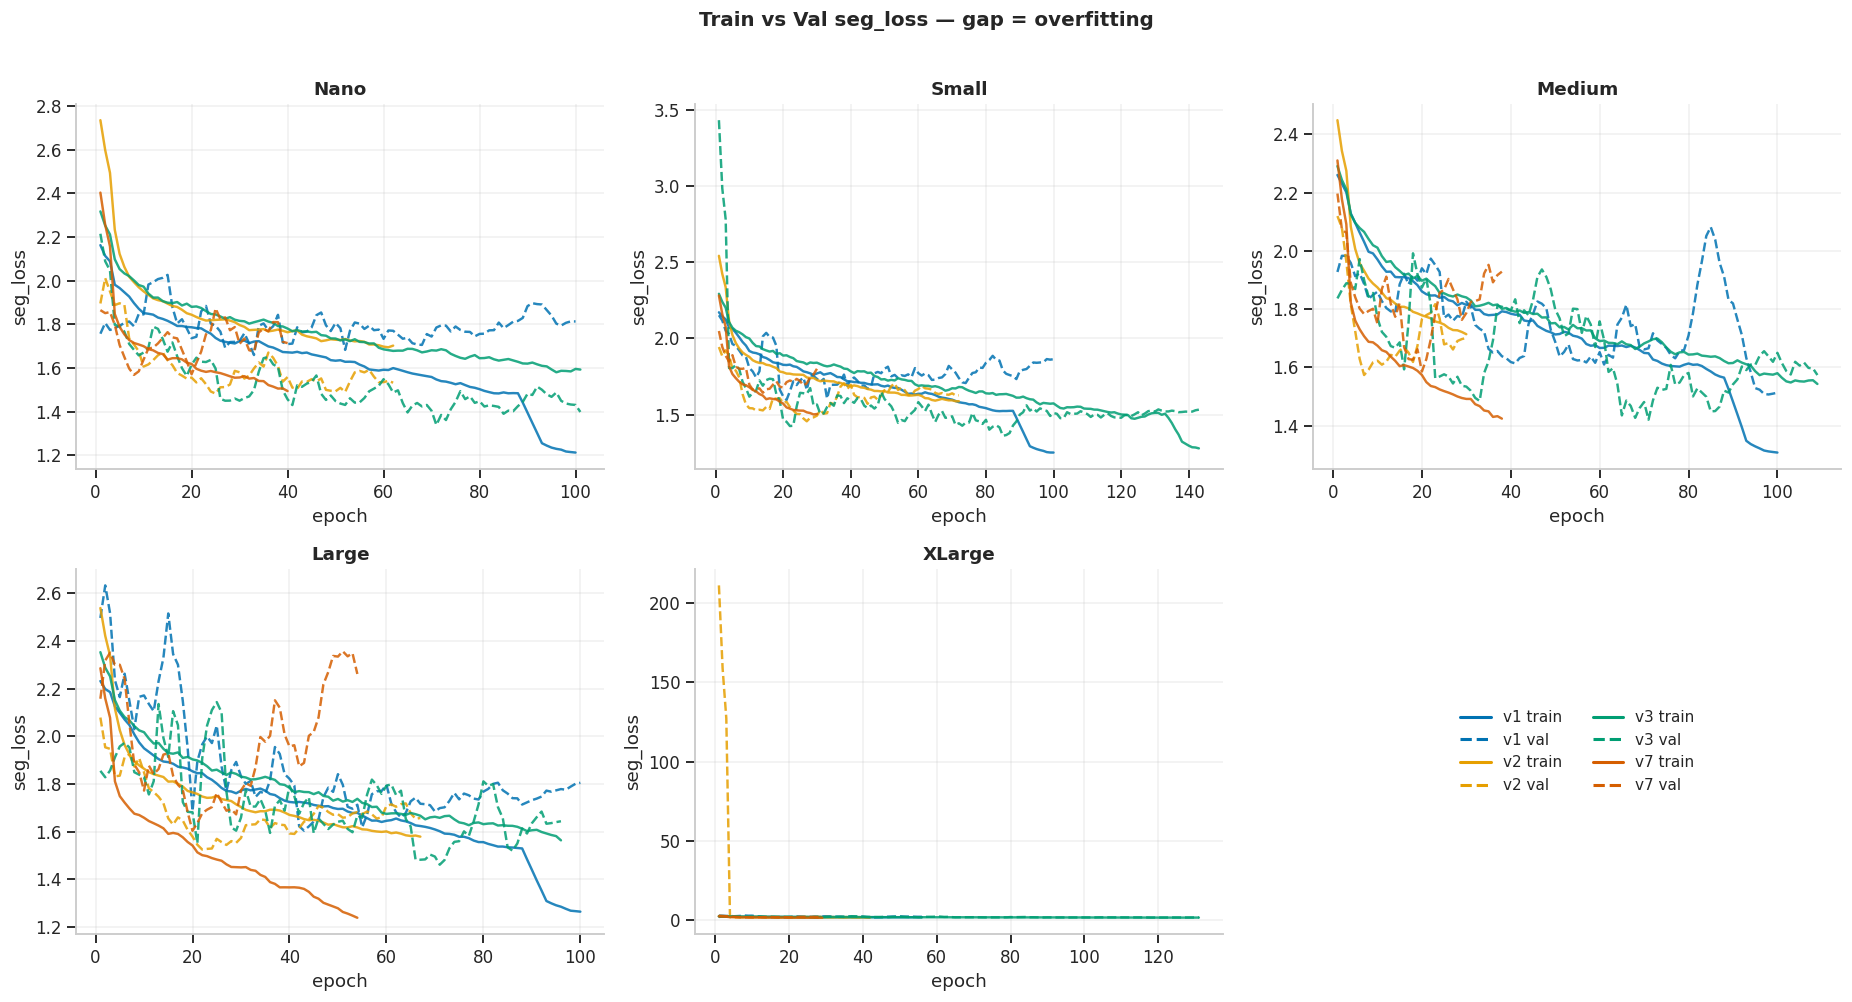

### Overfit gap no best ep (val − train seg_loss)

Version,v1,v2,v3,v7
Model,,,,
Nano,-0.074,-0.414,-0.406,-0.042
Small,+0.071,-0.246,-0.309,+0.018
Medium,+0.196,-0.140,-0.382,-0.174
Large,+0.061,-0.319,-0.359,+0.134
XLarge,-0.287,-0.331,-0.184,-0.178


In [70]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

for i, m in enumerate(MODEL_ORDER):
    ax = axes[i]
    for v in VERSION_ORDER:
        sel = df_long[(df_long["Model"] == m) & (df_long["Version"] == v)]
        if sel.empty:
            continue
        df = sel.iloc[0]["_df"]
        if "train/seg_loss" not in df or "val/seg_loss" not in df:
            continue
        eps = df["epoch"].to_numpy()
        c = VERSION_PALETTE[v]
        ax.plot(eps, smooth(df["train/seg_loss"].to_numpy(), 5),
                color=c, lw=1.6, alpha=0.85, label=f"{v} train")
        ax.plot(eps, smooth(df["val/seg_loss"].to_numpy(), 5),
                color=c, lw=1.6, alpha=0.85, ls="--", label=f"{v} val")
    ax.set_title(f"{m}")
    ax.set_xlabel("epoch")
    ax.set_ylabel("seg_loss")
    ax.grid(True, alpha=0.3)

axes[-1].axis("off")
handles = []
for v in VERSION_ORDER:
    handles.append(plt.Line2D([0], [0], color=VERSION_PALETTE[v], lw=2, label=f"{v} train"))
    handles.append(plt.Line2D([0], [0], color=VERSION_PALETTE[v], lw=2, ls="--", label=f"{v} val"))
axes[-1].legend(handles=handles, loc="center", ncol=2, fontsize=10)

fig.suptitle("Train vs Val seg_loss — gap = overfitting", y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Tabela: gap absoluto val−train no best ep
display(Markdown("### Overfit gap no best ep (val − train seg_loss)"))
overfit_pivot = df_long.pivot(index="Model", columns="Version", values="Overfit gap (seg)")[VERSION_ORDER].reindex(MODEL_ORDER)
display(overfit_pivot.style.format("{:+.3f}").background_gradient(cmap="RdYlGn_r", axis=None))


## 13. LR efetivo (`lr/pg0` no meio do treino)

Mesmo `lr0` nominal, o LR efetivo varia entre versões por causa de:
- Optimizer scaling (MuSGD vs AdamW)
- Batch global (`nbs=64` divisor; batch=16 → LR×0.25)
- Warmup + cosine schedule


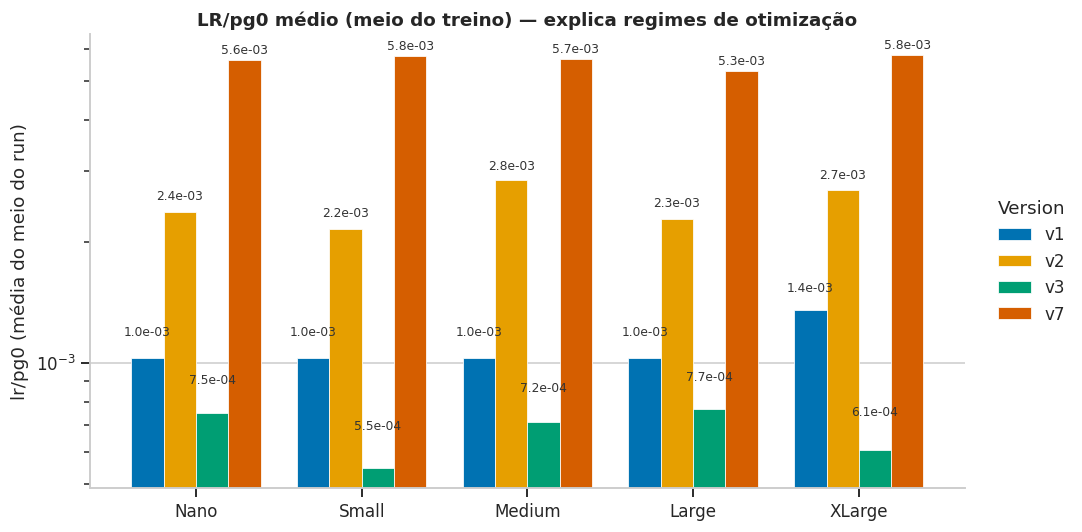

### LR diagnostics (start / mid / end)

In [71]:
lr_pivot = df_long.pivot(index="Model", columns="Version", values="lr/pg0 mid")[VERSION_ORDER].reindex(MODEL_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
lr_pivot.plot(
    kind="bar", ax=ax, width=0.78,
    color=[VERSION_PALETTE[v] for v in VERSION_ORDER],
    edgecolor="white", linewidth=0.5,
)
ax.set_title("LR/pg0 médio (meio do treino) — explica regimes de otimização")
ax.set_xlabel("")
ax.set_ylabel("lr/pg0 (média do meio do run)")
ax.set_yscale("log")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Version", loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(axis="x", visible=False)
add_value_labels(ax, fmt="{:.1e}", padding=0.02, fontsize=8)
plt.tight_layout()
plt.show()

display(Markdown("### LR diagnostics (start / mid / end)"))
display(
    df_long.pivot_table(index="Model", columns="Version",
                        values=["lr/pg0 start", "lr/pg0 mid", "lr/pg0 end"])
    .reindex(MODEL_ORDER).style.format("{:.2e}")
)


## 14. Pareto: `mAP@50-95` vs `Train time`

Cada ponto = (versão, modelo). Eixo-x = tempo de treino (min); eixo-y =
melhor mAP@50-95(M). **A frente Pareto** (linha) marca os runs que
dominam todos os outros (mais barato OU mais preciso).


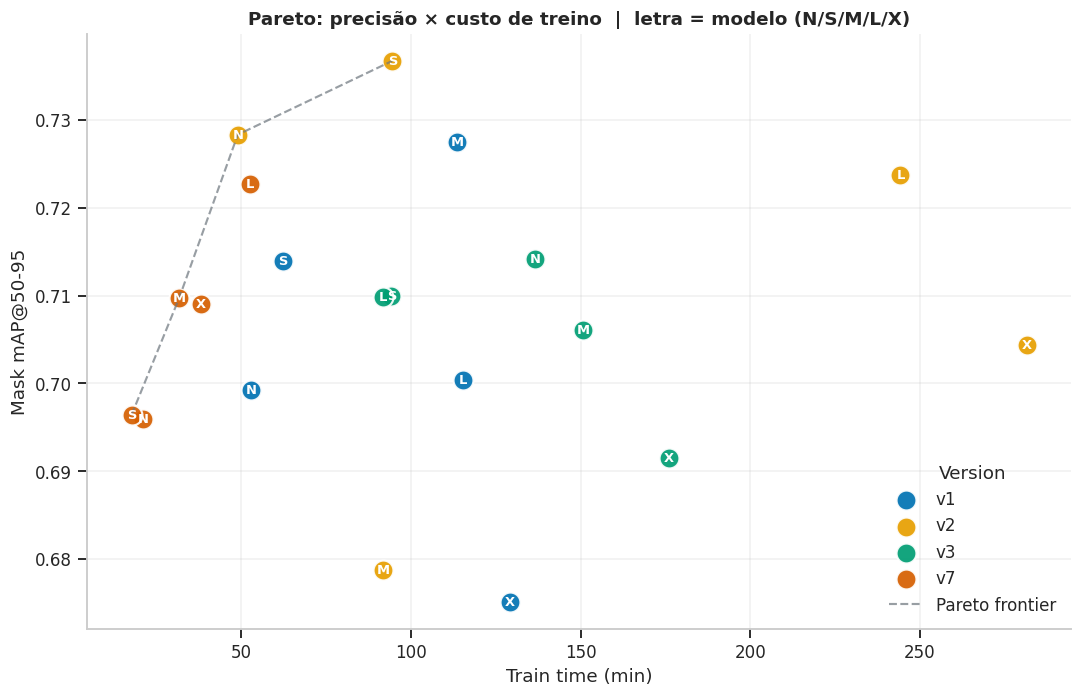

In [72]:
fig, ax = plt.subplots(figsize=(10, 6.5))

for v in VERSION_ORDER:
    sel = df_long[df_long["Version"] == v]
    if sel.empty:
        continue
    ax.scatter(
        sel["Train time (min)"], sel["Mask mAP@50-95"],
        s=170, color=VERSION_PALETTE[v], edgecolor="white", linewidth=1.4,
        label=v, alpha=0.92,
    )
    for _, r in sel.iterrows():
        ax.annotate(
            r["Model"][:1] if r["Model"] != "XLarge" else "X",
            (r["Train time (min)"], r["Mask mAP@50-95"]),
            ha="center", va="center", fontsize=8.5, color="white", fontweight="bold",
        )

# Pareto frontier (max y, min x)
pf_pts = df_long.dropna(subset=["Train time (min)", "Mask mAP@50-95"]).copy()
pf_pts = pf_pts.sort_values("Train time (min)")
front = []
best_y = -np.inf
for _, r in pf_pts.iterrows():
    if r["Mask mAP@50-95"] > best_y:
        front.append((r["Train time (min)"], r["Mask mAP@50-95"]))
        best_y = r["Mask mAP@50-95"]
if len(front) >= 2:
    fx, fy = zip(*front)
    ax.plot(fx, fy, color=NEUTRAL, ls="--", lw=1.4, alpha=0.7, label="Pareto frontier")

ax.set_xlabel("Train time (min)")
ax.set_ylabel("Mask mAP@50-95")
ax.set_title("Pareto: precisão × custo de treino  |  letra = modelo (N/S/M/L/X)")
ax.legend(title="Version", loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Diff de hiperparâmetros entre versões

Mostra os hiperparâmetros que mudaram entre as versões — útil para conectar
**diferenças de performance** com **diferenças de config**.


In [73]:
hp_cols = ["optimizer", "lr0", "amp", "batch", "epochs (cfg)",
           "close_mosaic", "erasing", "weight_decay", "dropout"]

# Pega os args do run "Small" (representativo) por versão
hp = (df_long[df_long["Model"] == "Small"][["Version"] + hp_cols]
      .drop_duplicates(subset=["Version"]).set_index("Version").reindex(VERSION_ORDER))


def style_diff(col: pd.Series):
    """Highlight rows where the value differs from v1 (or first existing version)."""
    if col.dropna().empty:
        return ["" for _ in col]
    ref = col.dropna().iloc[0]
    return [
        "background-color: #FFF3CD" if (str(v) != str(ref)) else ""
        for v in col
    ]


display(Markdown("### Hiperparâmetros chave (run `Small` como referência)"))
display(hp.T.style.apply(style_diff, axis=1).set_caption("Amarelo = difere da primeira versão"))


### Hiperparâmetros chave (run `Small` como referência)

Version,v1,v2,v3,v7
optimizer,auto,MuSGD,AdamW,MuSGD
lr0,0.010000,0.001000,0.001000,0.002000
amp,True,False,True,True
batch,16,-1,16,32
epochs (cfg),100,100,150,120
close_mosaic,10,10,15,15
erasing,0.400000,0.400000,0.000000,0.000000
weight_decay,0.000500,0.000500,0.001000,0.000500
dropout,0.000000,0.000000,0.100000,0.000000


## 16. Heatmap geral — todas as métricas, todos os modelos × versões

Visão consolidada. Cada célula é normalizada por linha (métrica) para
comparabilidade visual; **mais escuro = melhor para aquela métrica**.
Para métricas onde "menor é melhor" (loss, tempo), a escala é invertida.


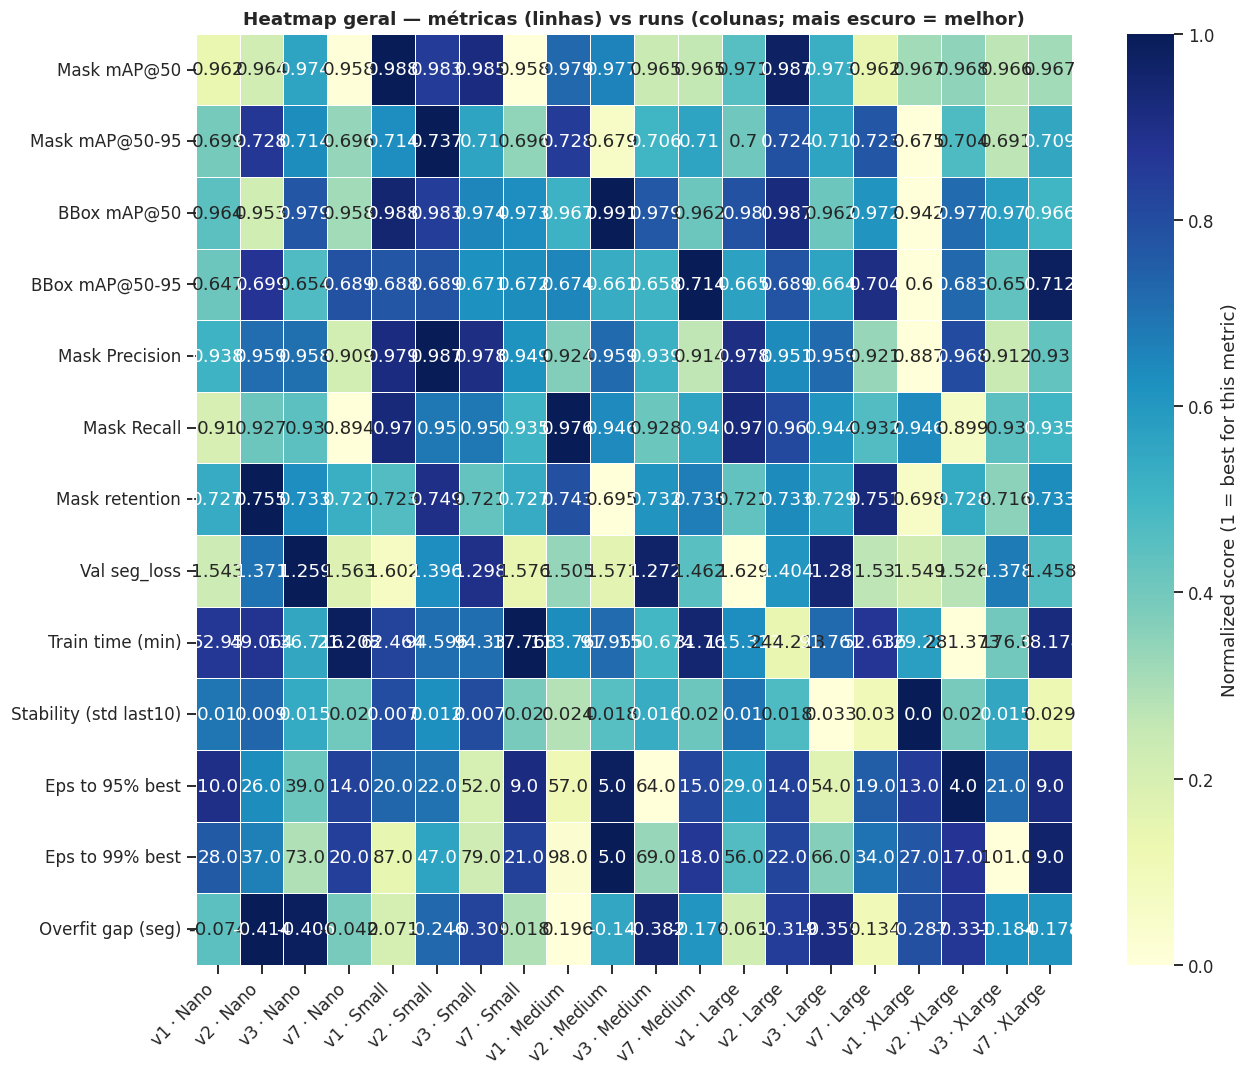

In [74]:
heat_metrics_higher_better = [
    "Mask mAP@50", "Mask mAP@50-95", "BBox mAP@50", "BBox mAP@50-95",
    "Mask Precision", "Mask Recall", "Mask retention",
]
heat_metrics_lower_better = [
    "Val seg_loss", "Train time (min)", "Stability (std last10)",
    "Eps to 95% best", "Eps to 99% best", "Overfit gap (seg)",
]

heat = df_long.copy()
heat["__col__"] = heat["Version"].astype(str) + " · " + heat["Model"].astype(str)
col_order = [f"{v} · {m}" for m in MODEL_ORDER for v in VERSION_ORDER]

rows_data = {}
for met in heat_metrics_higher_better + heat_metrics_lower_better:
    if met not in heat:
        continue
    sub = heat.set_index("__col__")[met].reindex(col_order)
    if met in heat_metrics_lower_better:
        # Inverte: maior = pior na escala original → mostramos como negativo da normalização
        norm = (sub.max() - sub) / (sub.max() - sub.min() + 1e-12)
    else:
        norm = (sub - sub.min()) / (sub.max() - sub.min() + 1e-12)
    rows_data[met] = norm

heat_norm = pd.DataFrame(rows_data).T
heat_raw = heat.set_index("__col__")[heat_metrics_higher_better + heat_metrics_lower_better].T.reindex(columns=col_order)

fig, ax = plt.subplots(figsize=(max(11, 0.6 * len(col_order)), 0.65 * len(heat_norm) + 1.5))
sns.heatmap(
    heat_norm,
    annot=heat_raw.round(3), fmt="",
    cmap="YlGnBu", cbar_kws={"label": "Normalized score (1 = best for this metric)"},
    linewidths=0.4, linecolor="white", ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Heatmap geral — métricas (linhas) vs runs (colunas; mais escuro = melhor)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 17. Insights automáticos

Conclusões geradas a partir dos dados — útil para o resumo executivo do
relatório.


In [75]:
insights = []

# 1. Champion overall
overall_champ = df_long.loc[df_long["Mask mAP@50-95"].idxmax()]
insights.append(
    f"**Champion absoluto**: `{overall_champ['Version']}` em `{overall_champ['Model']}` "
    f"com Mask mAP@50-95 = **{overall_champ['Mask mAP@50-95']:.4f}** "
    f"(best ep {overall_champ['Best epoch']})."
)

# 2. Versão mais consistente (média ranks)
ranks = pivot_main.rank(axis=1, ascending=False).mean(axis=0)
best_avg = ranks.idxmin()
insights.append(
    f"**Versão mais consistente** (menor rank médio em mAP@50-95): `{best_avg}` "
    f"(rank médio = {ranks[best_avg]:.2f})."
)

# 3. Maior melhoria observada
deltas = []
for ref in VERSION_ORDER:
    for other in VERSION_ORDER:
        if ref == other:
            continue
        for m in MODEL_ORDER:
            if not (m in pivot_main.index and ref in pivot_main.columns and other in pivot_main.columns):
                continue
            d = pivot_main.loc[m, other] - pivot_main.loc[m, ref]
            if np.isfinite(d):
                deltas.append((m, ref, other, d))
deltas.sort(key=lambda t: t[3], reverse=True)
if deltas:
    m, ref, other, d = deltas[0]
    insights.append(f"**Maior ganho**: {ref} → {other} em `{m}` ({d:+.4f}).")
    m, ref, other, d = deltas[-1]
    insights.append(f"**Maior regressão**: {ref} → {other} em `{m}` ({d:+.4f}).")

# 4. Run mais estável
stab = df_long.dropna(subset=["Stability (std last10)"])
if not stab.empty:
    stable = stab.loc[stab["Stability (std last10)"].idxmin()]
    insights.append(
        f"**Run mais estável** (menor std nas últimas 10 ep): "
        f"`{stable['Version']}/{stable['Model']}` (σ = {stable['Stability (std last10)']:.4f})."
    )

# 5. Run mais rápido a convergir
conv = df_long.dropna(subset=["Eps to 95% best"])
if not conv.empty:
    fast = conv.loc[conv["Eps to 95% best"].idxmin()]
    insights.append(
        f"**Convergência mais rápida**: `{fast['Version']}/{fast['Model']}` "
        f"atingiu 95% do best em {int(fast['Eps to 95% best'])} épocas."
    )

# 6. Best efficiency (mAP / min)
df_long["Efficiency"] = df_long["Mask mAP@50-95"] / df_long["Train time (min)"]
eff = df_long.loc[df_long["Efficiency"].idxmax()]
insights.append(
    f"**Mais eficiente** (mAP@50-95 por minuto): `{eff['Version']}/{eff['Model']}` "
    f"({eff['Efficiency']:.4f} mAP/min)."
)

display(Markdown("### Destaques\n\n" + "\n\n".join(f"- {x}" for x in insights)))


### Destaques

- **Champion absoluto**: `v2` em `Small` com Mask mAP@50-95 = **0.7368** (best ep 47).

- **Versão mais consistente** (menor rank médio em mAP@50-95): `v2` (rank médio = 1.80).

- **Maior ganho**: v2 → v1 em `Medium` (+0.0487).

- **Maior regressão**: v1 → v2 em `Medium` (-0.0487).

- **Run mais estável** (menor std nas últimas 10 ep): `v1/XLarge` (σ = 0.0000).

- **Convergência mais rápida**: `v2/XLarge` atingiu 95% do best em 4 épocas.

- **Mais eficiente** (mAP@50-95 por minuto): `v7/Small` (0.0392 mAP/min).

## 18. Export — tabela completa para CSV

Para incluir em relatório, planilha ou outro notebook.


In [76]:
export_cols = [
    "Version", "Model",
    "Mask mAP@50", "Mask mAP@50-95", "BBox mAP@50", "BBox mAP@50-95",
    "Mask Precision", "Mask Recall", "Mask retention",
    "Val seg_loss", "Train seg_loss", "Overfit gap (seg)",
    "Best epoch", "Total epochs", "Train time (min)",
    "Eps to 95% best", "Eps to 99% best", "Stability (std last10)",
    "lr/pg0 start", "lr/pg0 mid", "lr/pg0 end",
    "optimizer", "lr0", "amp", "batch", "weight_decay", "dropout",
]
export = df_long[export_cols].copy()

out = BASE_DIR / "logs" / "compare_versions_summary.csv"
try:
    export.to_csv(out, index=False)
    print(f"Salvo: {out}")
except OSError as e:
    print(f"(sem permissão para salvar em {out}: {e})")

display(export.style.format(precision=4))


Salvo: /home/antoniovinicius/projects/sandbox_yolo26/logs/compare_versions_summary.csv


,Version,Model,Mask mAP@50,Mask mAP@50-95,BBox mAP@50,BBox mAP@50-95,Mask Precision,Mask Recall,Mask retention,Val seg_loss,Train seg_loss,Overfit gap (seg),Best epoch,Total epochs,Train time (min),Eps to 95% best,Eps to 99% best,Stability (std last10),lr/pg0 start,lr/pg0 mid,lr/pg0 end,optimizer,lr0,amp,batch,weight_decay,dropout
0,v1,Nano,0.9617,0.6993,0.9637,0.6472,0.9381,0.9098,0.7272,1.5428,1.6164,-0.0735,51,100,52.9502,10,28,0.0104,0.0017,0.0010,0.0001,auto,0.0100,True,16,0.0005,0.0000
1,v2,Nano,0.9641,0.7283,0.9529,0.6994,0.9587,0.9274,0.7555,1.3708,1.7845,-0.4138,37,62,49.0640,26,37,0.0090,0.0025,0.0024,0.0011,MuSGD,0.0010,False,-1,0.0005,0.0000
2,v3,Nano,0.9745,0.7142,0.9795,0.6537,0.9577,0.9300,0.7329,1.2589,1.6646,-0.4057,73,101,136.7163,39,73,0.0154,0.0008,0.0008,0.0003,AdamW,0.0010,True,16,0.0010,0.1000
3,v7,Nano,0.9578,0.6960,0.9575,0.6893,0.9085,0.8938,0.7266,1.5625,1.6043,-0.0418,20,40,21.2078,14,20,0.0200,0.0045,0.0056,0.0047,MuSGD,0.0020,True,32,0.0005,0.0000
4,v1,Small,0.9876,0.7140,0.9883,0.6879,0.9788,0.9700,0.7230,1.6019,1.5306,0.0713,87,100,62.4640,20,87,0.0067,0.0017,0.0010,0.0001,auto,0.0100,True,16,0.0005,0.0000
5,v2,Small,0.9831,0.7368,0.9831,0.6890,0.9872,0.9500,0.7494,1.3960,1.6423,-0.2463,47,72,94.5962,22,47,0.0124,0.0026,0.0022,0.0007,MuSGD,0.0010,False,-1,0.0005,0.0000
6,v3,Small,0.9851,0.7099,0.9738,0.6711,0.9780,0.9500,0.7207,1.2979,1.6069,-0.3090,87,143,94.3303,52,79,0.0067,0.0009,0.0005,0.0000,AdamW,0.0010,True,16,0.0010,0.1000
7,v7,Small,0.9576,0.6964,0.9728,0.6723,0.9493,0.9353,0.7272,1.5760,1.5579,0.0181,21,30,17.7677,9,21,0.0204,0.0040,0.0058,0.0052,MuSGD,0.0020,True,32,0.0005,0.0000
8,v1,Medium,0.9794,0.7275,0.9670,0.6741,0.9242,0.9755,0.7428,1.5047,1.3092,0.1955,99,100,113.7672,57,98,0.0240,0.0017,0.0010,0.0001,auto,0.0100,True,8,0.0005,0.0000
9,v2,Medium,0.9774,0.6788,0.9906,0.6611,0.9595,0.9464,0.6945,1.5714,1.7118,-0.1404,29,30,91.9545,5,5,0.0183,0.0020,0.0028,0.0025,MuSGD,0.0010,False,-1,0.0005,0.0000


## 19. Inferência qualitativa — comparação visual em imagens fixas

Esta seção compara as **predições visuais** de cada versão sobre **as
mesmas imagens** do conjunto de teste. Diferente da seção anterior (que
mostra batches gerados aleatoriamente pelo Ultralytics), aqui:

* Você escolhe **explicitamente** quais imagens analisar editando a lista
  `IMAGE_STEMS` abaixo. Isso garante reprodutibilidade e permite focar em
  casos específicos (lesão pequena, baixo contraste, presença de pelo etc).
* Cada imagem-âncora é renderizada em **uma figura única** com `1 GT + N
  paineis lado a lado` (v1, v2, v3, v7, v8 (depende do que existe nos logs)), tornando a comparação visual
  imediata.
* Sob cada painel: o **IoU** entre a máscara predita e a ground-truth, em
  pixels — métrica direta da qualidade da segmentação naquela imagem.
* As figuras são salvas em `figures/qualitative/` para uso posterior em
  apresentações.

In [ ]:
# ============================================================================
# Configuração da inferência qualitativa
# ============================================================================
# Edite aqui:
#   * IMAGE_STEMS: nomes (sem extensão) das imagens do conjunto de teste a
#     comparar. Default = 6 âncoras escolhidas para cobrir casos variados.
#     Use apenas o stem (ex: "ISIC_0012486"), o código procura .jpg/.png.
#   * MODEL_SIZE_FOR_QUAL: qual tamanho usar quando o eixo for "versão".
#   * TEST_IMAGES_DIR / TEST_LABELS_DIR: paths para o split de teste.

IMAGE_STEMS = [
    "ISIC_0012456_jpg.rf.96249201c362db5395d5aa749f377e94",
    "ISIC_0015169_jpg.rf.cd4b092e76b2b9987890126c3996abef",
    "ISIC_0015970_jpg.rf.696b869a9a5ada775be201c654d87b8c",
    "ISIC_0017434_jpg.rf.5bf254cc1f70130ffa9d4fbbe3b7669e",
    "ISIC_0020081_jpg.rf.975846c0d6c96bafc7af3d96f5aa684d",
    "ISIC_0036343_jpg.rf.155427d08d147b7f7479b26e9833de9c",
]

MODEL_SIZE_FOR_QUAL = "Small"   # qual tamanho usar para comparar versões

# Default = teste do ISIC. Caso queira inspecionar o PH2 (out-of-distribution),
# troque para BASE_DIR / "datasets/ph2/test/images" e _labels.
TEST_IMAGES_DIR = BASE_DIR / "datasets" / "isic_2018_task1_yolo26" / "test" / "images"
TEST_LABELS_DIR = BASE_DIR / "datasets" / "isic_2018_task1_yolo26" / "test" / "labels"

# AXIS_CONFIG mapeia rótulo do eixo -> path do best.pt. Construído a partir
# do dict VERSIONS para rodar o tamanho `MODEL_SIZE_FOR_QUAL` em cada versão.
AXIS_CONFIG = {}
for v, cfg in VERSIONS.items():
    sub = cfg["model_dirs"].get(MODEL_SIZE_FOR_QUAL)
    if sub is None:
        continue
    wpath = cfg["log_dir"] / sub / "weights" / "best.pt"
    AXIS_CONFIG[v] = wpath

AXIS_PALETTE = {v: VERSION_PALETTE.get(v, "#444") for v in AXIS_CONFIG}

print(f"Eixo: versões  |  Modelo: {MODEL_SIZE_FOR_QUAL}")
for k, v in AXIS_CONFIG.items():
    print(f"  {k:6s} {'[OK]' if v.exists() else '[MISSING]':9s} {v}")
print(f"\nImagens-âncora: {IMAGE_STEMS}")
print(f"Test images dir: {TEST_IMAGES_DIR}  ", "[OK]" if TEST_IMAGES_DIR.exists() else "[MISSING]")


Eixo: versões  |  Modelo: Small
  v1     [OK]      /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v1/yolo26_small_ft_isic_2018_task_1_100/weights/best.pt
  v2     [OK]      /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v2/yolo26_small_ft_isic_2018_task_1_100/weights/best.pt
  v3     [OK]      /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v3/yolo26_small_ft_isic_2018/weights/best.pt
  v7     [OK]      /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v7/yolo26_small_ft_isic_2018_v7/weights/best.pt

Imagens-âncora: ['ISIC_0012456_jpg.rf.96249201c362db5395d5aa749f377e94', 'ISIC_0015169_jpg.rf.cd4b092e76b2b9987890126c3996abef', 'ISIC_0015970_jpg.rf.696b869a9a5ada775be201c654d87b8c', 'ISIC_0017434_jpg.rf.5bf254cc1f70130ffa9d4fbbe3b7669e', 'ISIC_0020081_jpg.rf.975846c0d6c96bafc7af3d96f5aa684d', 'ISIC_0036343_jpg.rf.155427d08d147b7f7479b26e9833de9c']
Test images dir: /home/antonioviniciu

In [78]:
try:
    import cv2
    from ultralytics import YOLO
    _qual_ok = True
except ImportError as e:
    print(f"OpenCV / Ultralytics não disponíveis: {e} — pulando seção qualitativa.")
    _qual_ok = False

import time

ALPHA = 0.45
COLOR_GT_BGR   = (113, 204,  46)   # lime green
COLOR_PRED_BGR = ( 60,  20, 220)   # crimson red
SAVE_DIR = BASE_DIR / "figures" / "qualitative"


def _read_gt_polys(label_path: Path, h: int, w: int):
    polys = []
    if label_path.exists():
        with label_path.open() as fh:
            for line in fh:
                parts = line.strip().split()
                if len(parts) > 1:
                    coords = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)
                    coords[:, 0] *= w
                    coords[:, 1] *= h
                    polys.append(coords.astype(np.int32))
    return polys


def _polys_to_mask(polys, h: int, w: int) -> np.ndarray:
    m = np.zeros((h, w), dtype=np.uint8)
    for p in polys:
        cv2.fillPoly(m, [p], 1)
    return m


def _iou(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter) / float(union) if union > 0 else float("nan")


def _draw_polys(img, polys, color_bgr, alpha=ALPHA, outline=(255, 255, 255)):
    for p in polys:
        ov = img.copy()
        cv2.fillPoly(ov, [p], color_bgr)
        cv2.addWeighted(ov, alpha, img, 1 - alpha, 0, img)
        cv2.polylines(img, [p], isClosed=True, color=outline, thickness=3, lineType=cv2.LINE_8)


def _resolve_image(stem: str, img_dir: Path) -> Path | None:
    for ext in (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"):
        p = img_dir / f"{stem}{ext}"
        if p.exists():
            return p
    return None


def compare_qualitative(image_stems, axis_config, axis_palette,
                        test_images_dir, test_labels_dir,
                        save_prefix: str, alt_image_dirs: dict | None = None):
    """Render side-by-side qualitative comparison.

    alt_image_dirs (optional): for color-space comparison, maps axis_label ->
      images_dir. The model loaded for that axis will be inferred on the
      same-stem image from that dir. GT polys always come from the canonical
      test_labels_dir (RGB layout, since geometry is the same)."""
    if not _qual_ok:
        return
    if not test_images_dir.exists():
        print(f"⚠ Test images dir não encontrada: {test_images_dir}")
        return

    # Carrega modelos uma vez
    print("Carregando modelos…")
    loaded = {}
    for axis, wpath in axis_config.items():
        if not wpath.exists():
            print(f"  ⚠ Pesos faltando para {axis}: {wpath}")
            continue
        loaded[axis] = YOLO(wpath)
    if not loaded:
        print("Nenhum modelo carregado — pulando.")
        return

    SAVE_DIR.mkdir(parents=True, exist_ok=True)

    for stem in image_stems:
        img_path = _resolve_image(stem, test_images_dir)
        if img_path is None:
            print(f"  ⚠ Imagem não encontrada (test/): {stem}")
            continue
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            print(f"  ⚠ Falha lendo {img_path}")
            continue
        h, w = img_bgr.shape[:2]

        gt_polys = _read_gt_polys(test_labels_dir / f"{stem}.txt", h, w)
        gt_mask = _polys_to_mask(gt_polys, h, w)

        n_panels = 1 + len(loaded)  # GT + axes
        cols = min(n_panels, 4)
        rows = (n_panels + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(4.6 * cols, 4.8 * rows))
        axes = np.atleast_1d(axes).flatten()

        # GT panel (sempre no slot 0)
        img_gt = img_bgr.copy()
        _draw_polys(img_gt, gt_polys, COLOR_GT_BGR)
        axes[0].imshow(cv2.cvtColor(img_gt, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Ground Truth", fontsize=12, fontweight="bold")
        axes[0].axis("off")

        # paineis por eixo
        for idx, (axis, model) in enumerate(loaded.items(), start=1):
            # imagem usada para inferência (pode ser HED/LAB)
            inf_path = img_path
            if alt_image_dirs and axis in alt_image_dirs:
                alt = _resolve_image(stem, alt_image_dirs[axis])
                if alt is not None:
                    inf_path = alt
            inf_img = cv2.imread(str(inf_path))
            if inf_img is None:
                axes[idx].axis("off")
                axes[idx].set_title(f"{axis}\n(read fail)", fontsize=11)
                continue

            t0 = time.perf_counter()
            res = model.predict(source=inf_img, conf=0.5, imgsz=640, verbose=False)
            dt_ms = (time.perf_counter() - t0) * 1000

            # canvas para visualização — sempre desenha sobre o RGB original
            disp = img_bgr.copy()
            # GT em verde por baixo
            for p in gt_polys:
                cv2.polylines(disp, [p], isClosed=True, color=COLOR_GT_BGR,
                              thickness=3, lineType=cv2.LINE_AA)

            pred_polys = []
            if res[0].masks is not None and len(res[0].masks.xy) > 0:
                for mxy in res[0].masks.xy:
                    pred_polys.append(mxy.astype(np.int32))
                _draw_polys(disp, pred_polys, COLOR_PRED_BGR)

            # IoU pixel-wise
            pred_mask = _polys_to_mask(pred_polys, h, w)
            iou_val = _iou(gt_mask, pred_mask)
            iou_str = f"IoU = {iou_val:.3f}" if not np.isnan(iou_val) else "IoU = n/a"

            axes[idx].imshow(cv2.cvtColor(disp, cv2.COLOR_BGR2RGB))
            color = axis_palette.get(axis, "#444")
            axes[idx].set_title(f"{axis}    {iou_str}\n{dt_ms:.1f} ms",
                                fontsize=11, color=color, fontweight="bold")
            axes[idx].axis("off")

        # off para slots vazios
        for j in range(n_panels, len(axes)):
            axes[j].axis("off")

        fig.suptitle(f"{img_path.name}", fontsize=13, y=1.02)
        plt.tight_layout()
        out_path = SAVE_DIR / f"{save_prefix}_{stem}.png"
        plt.savefig(out_path, dpi=130, bbox_inches="tight")
        plt.show()
        print(f"  saved → {out_path}")


Carregando modelos…


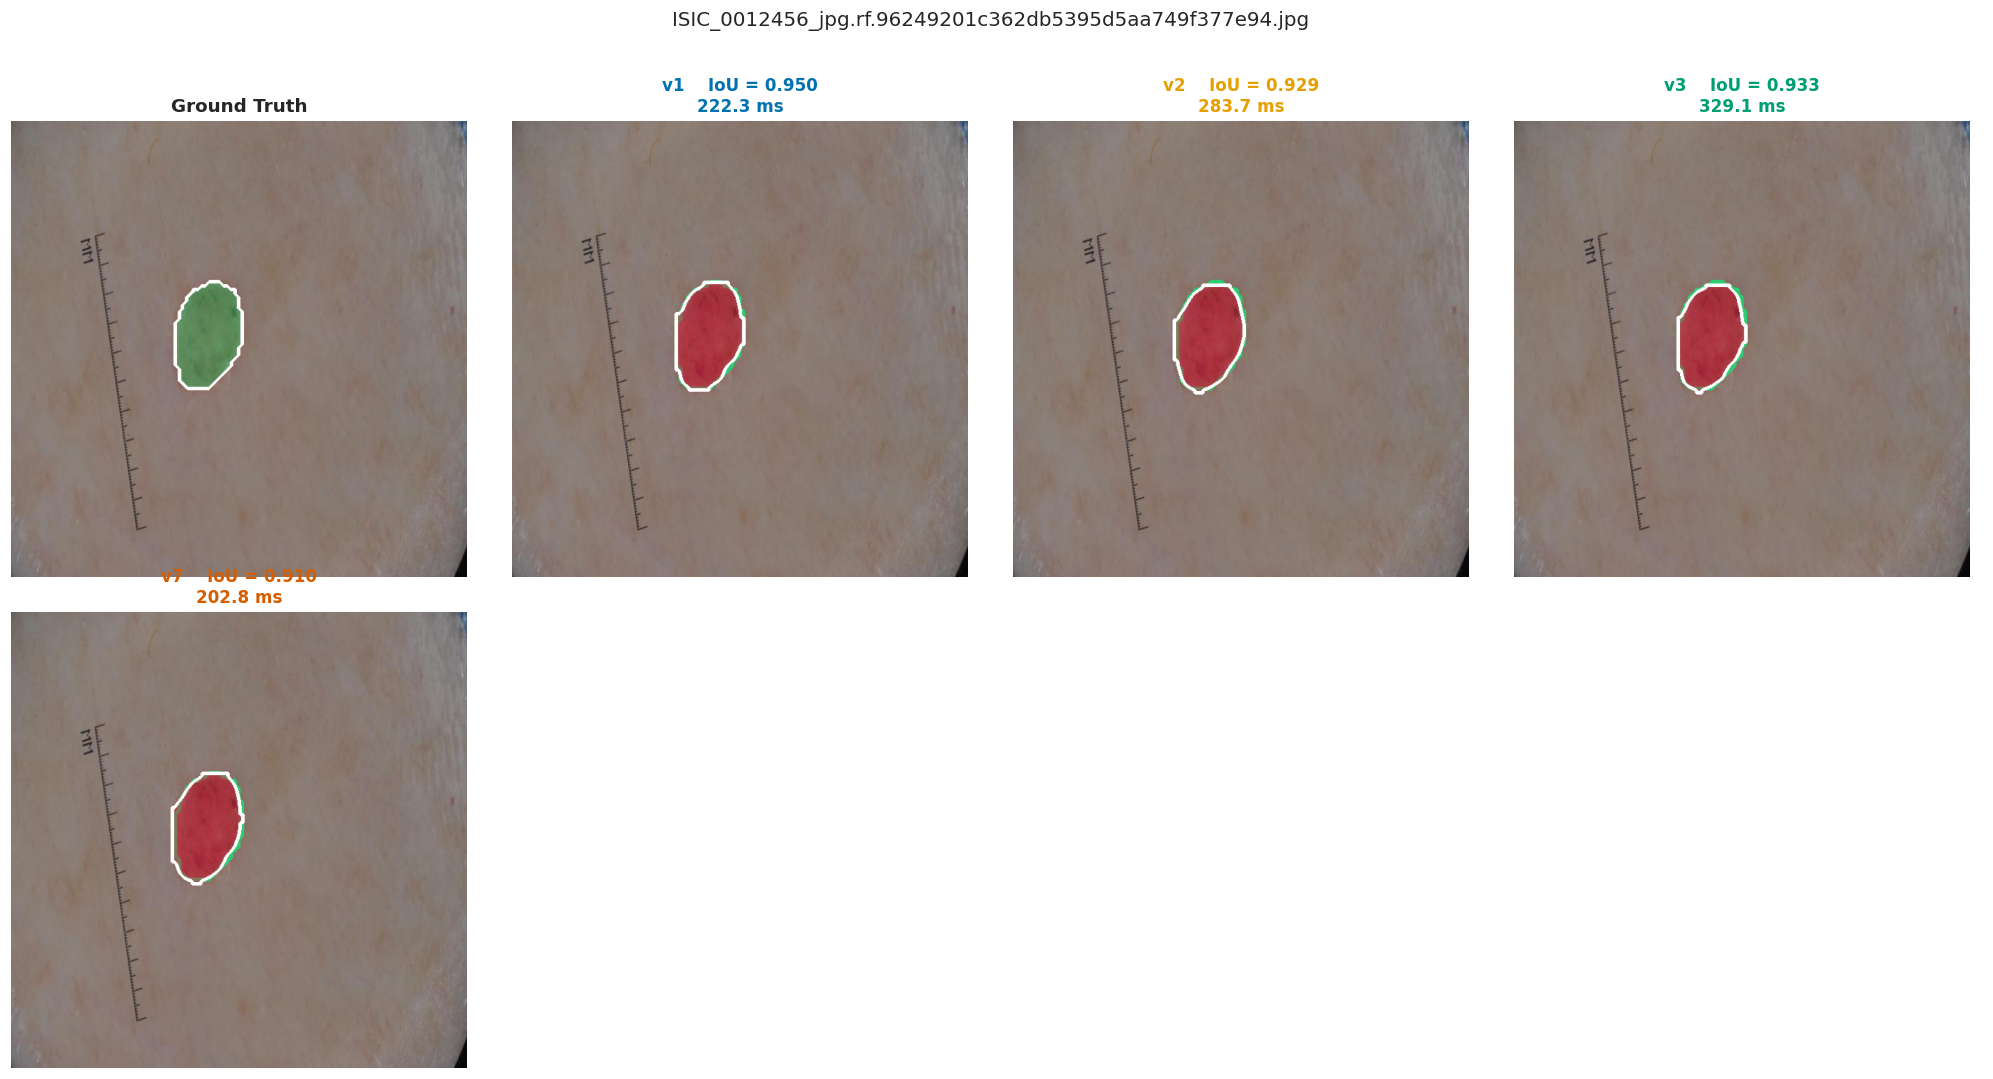

  saved → /home/antoniovinicius/projects/sandbox_yolo26/figures/qualitative/compare_versions_ISIC_0012456_jpg.rf.96249201c362db5395d5aa749f377e94.png


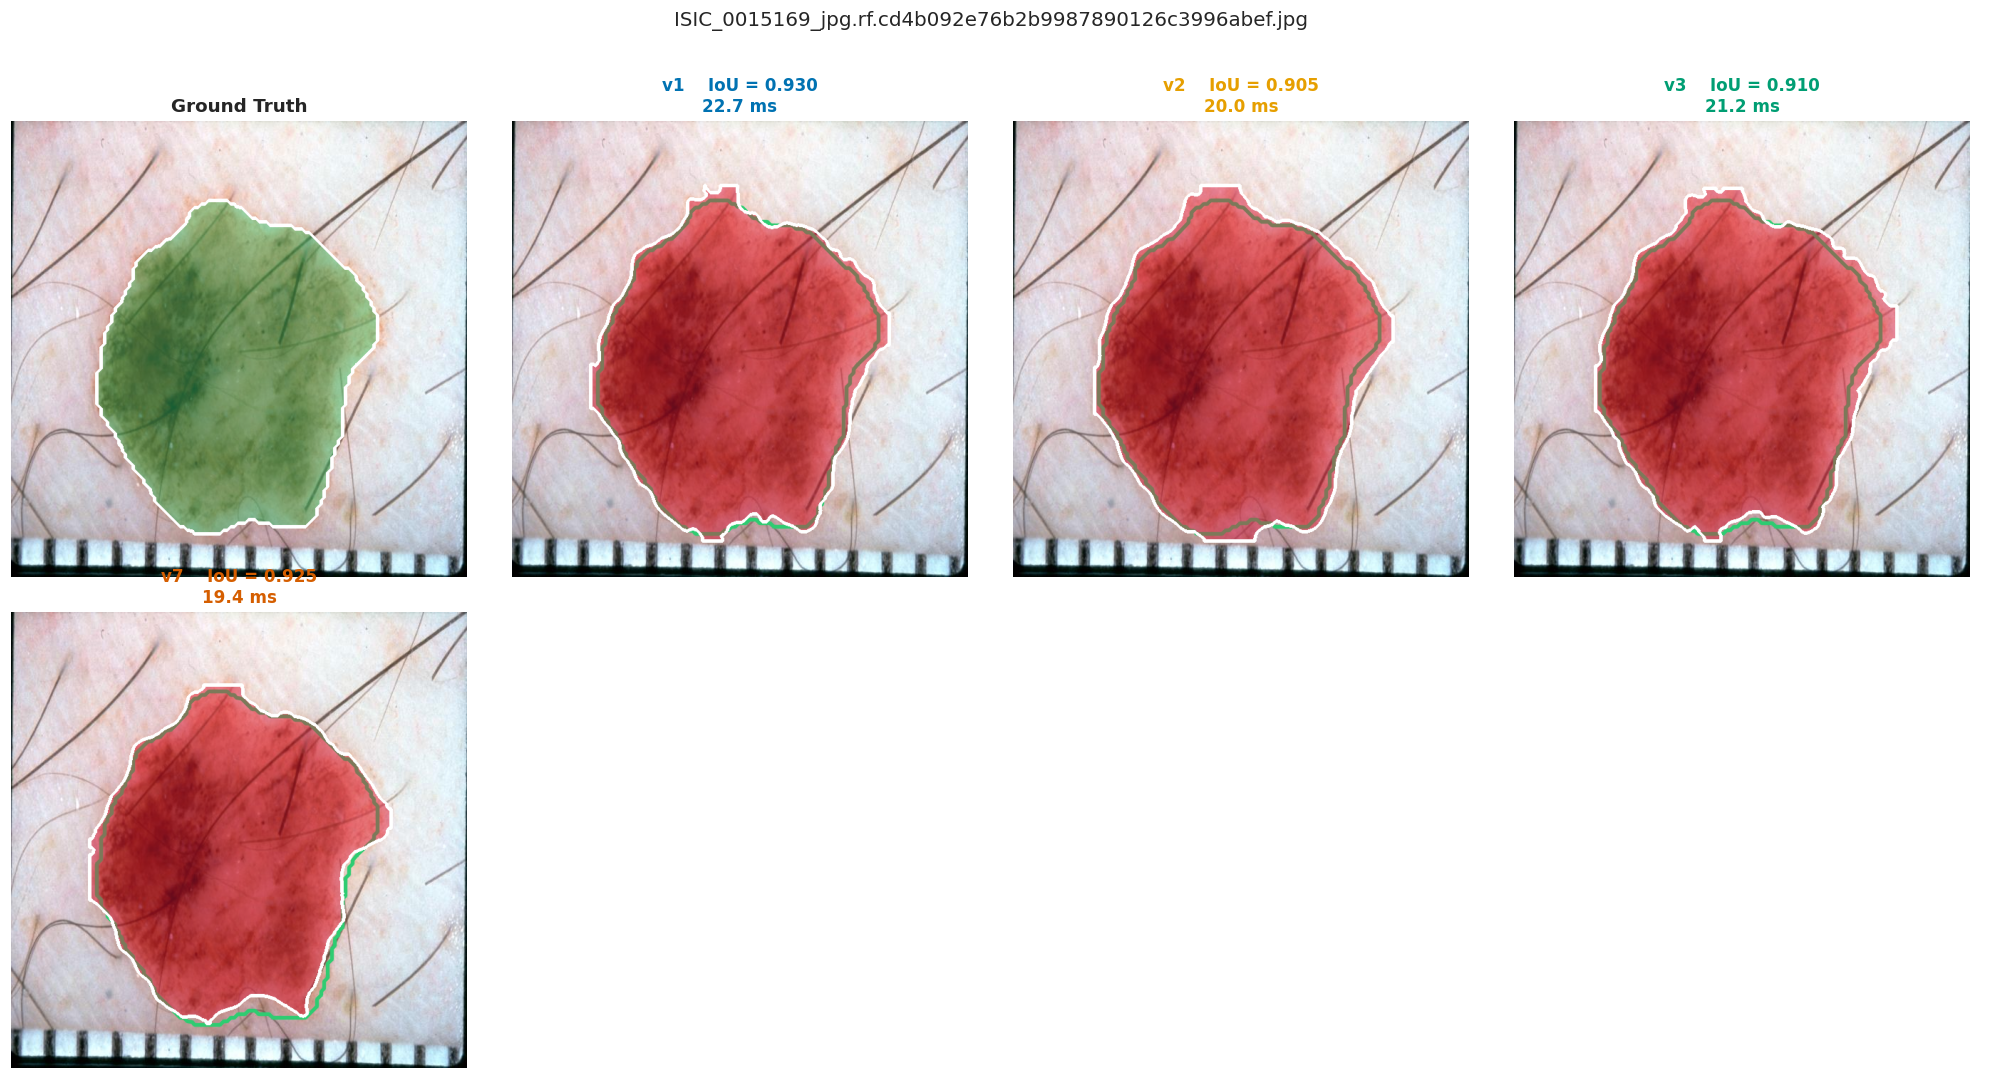

  saved → /home/antoniovinicius/projects/sandbox_yolo26/figures/qualitative/compare_versions_ISIC_0015169_jpg.rf.cd4b092e76b2b9987890126c3996abef.png


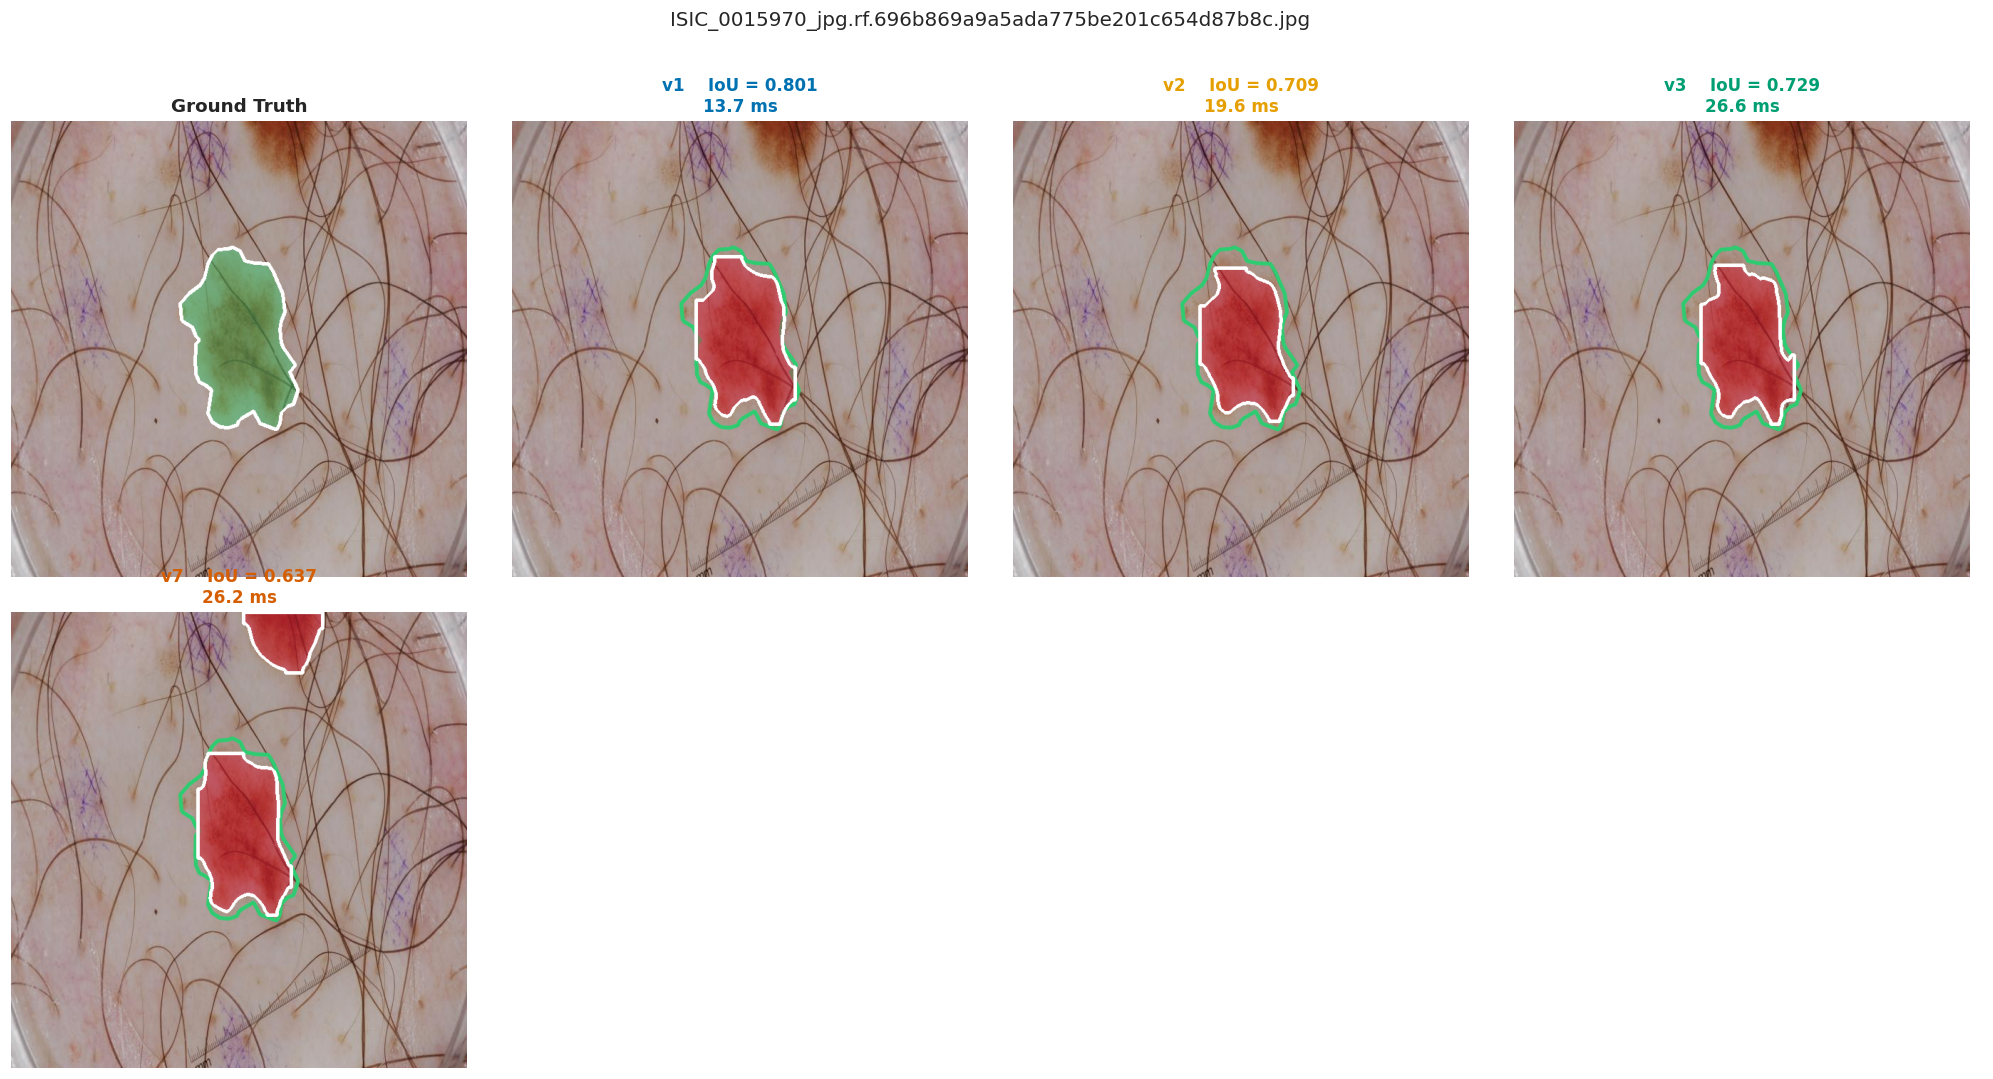

  saved → /home/antoniovinicius/projects/sandbox_yolo26/figures/qualitative/compare_versions_ISIC_0015970_jpg.rf.696b869a9a5ada775be201c654d87b8c.png


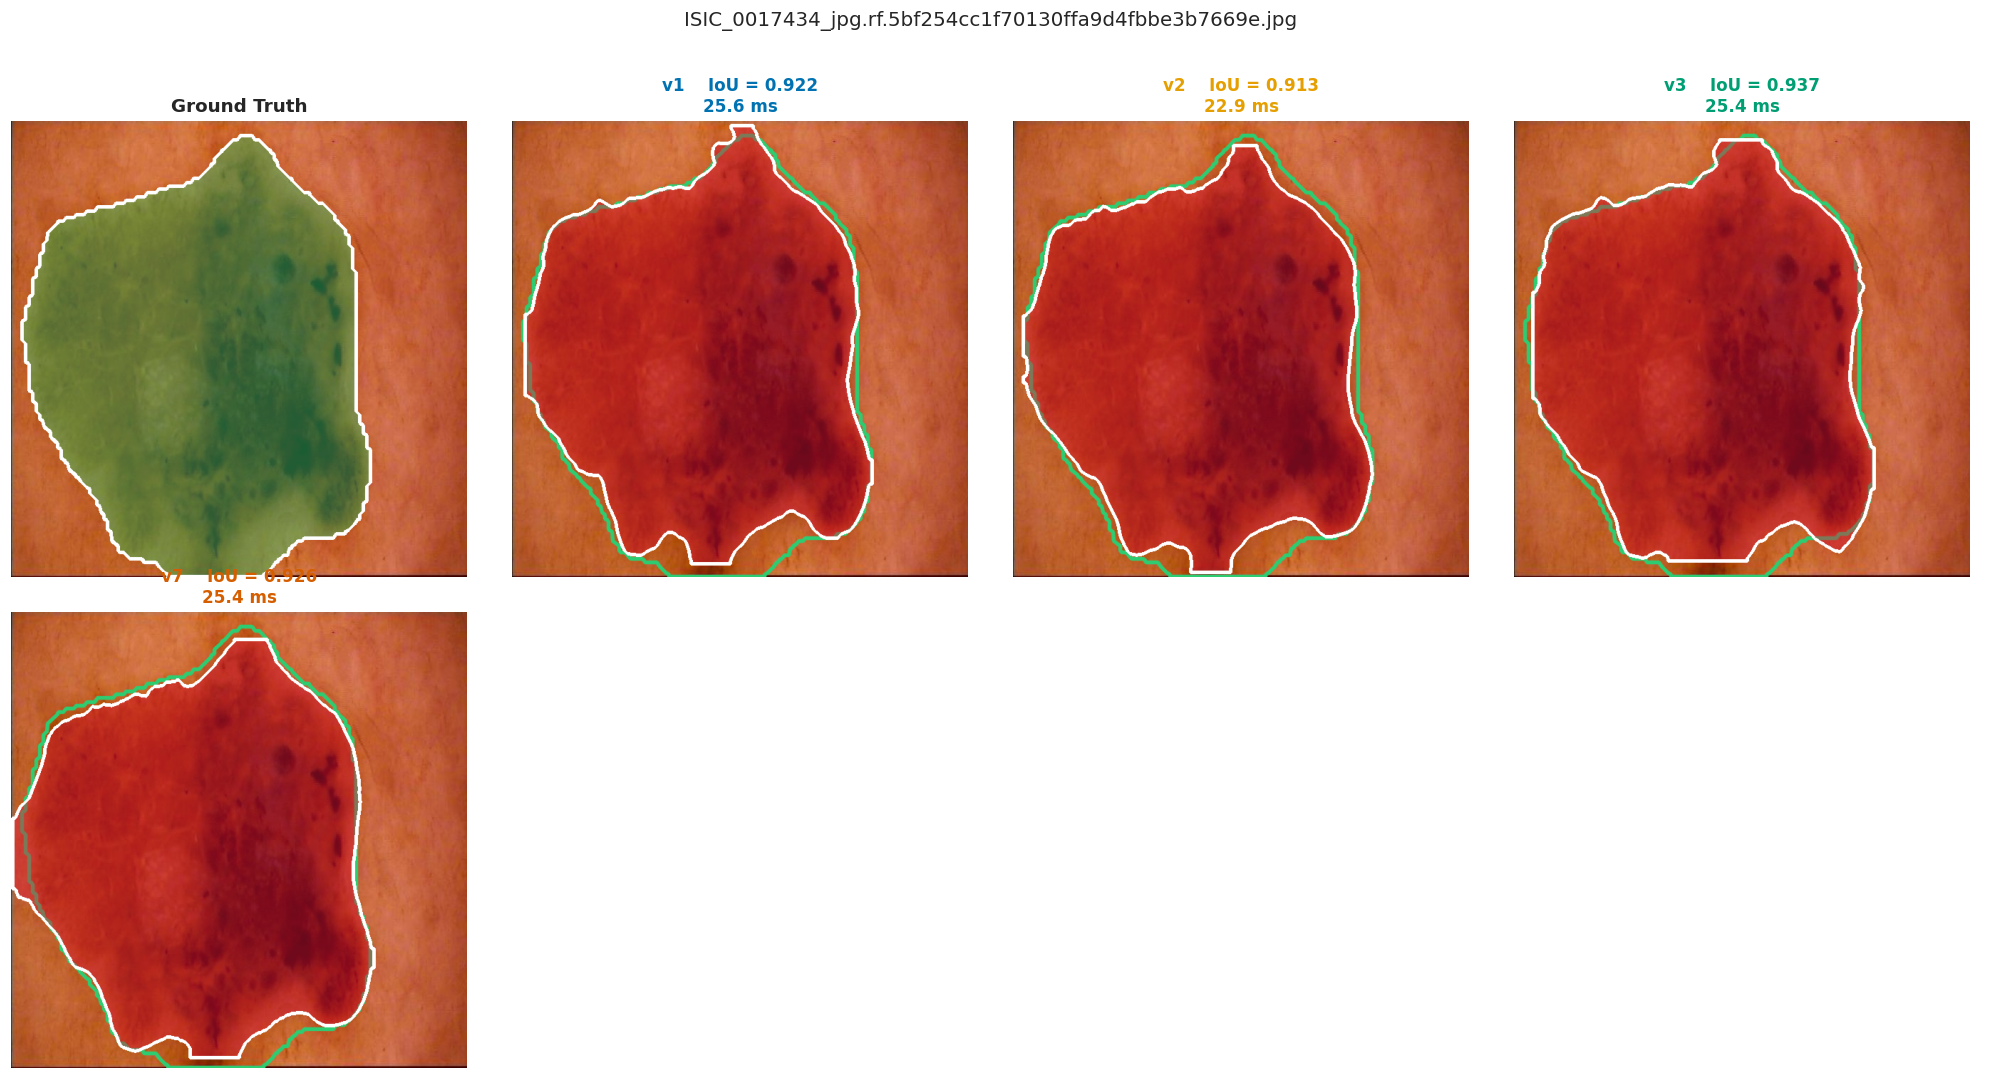

  saved → /home/antoniovinicius/projects/sandbox_yolo26/figures/qualitative/compare_versions_ISIC_0017434_jpg.rf.5bf254cc1f70130ffa9d4fbbe3b7669e.png


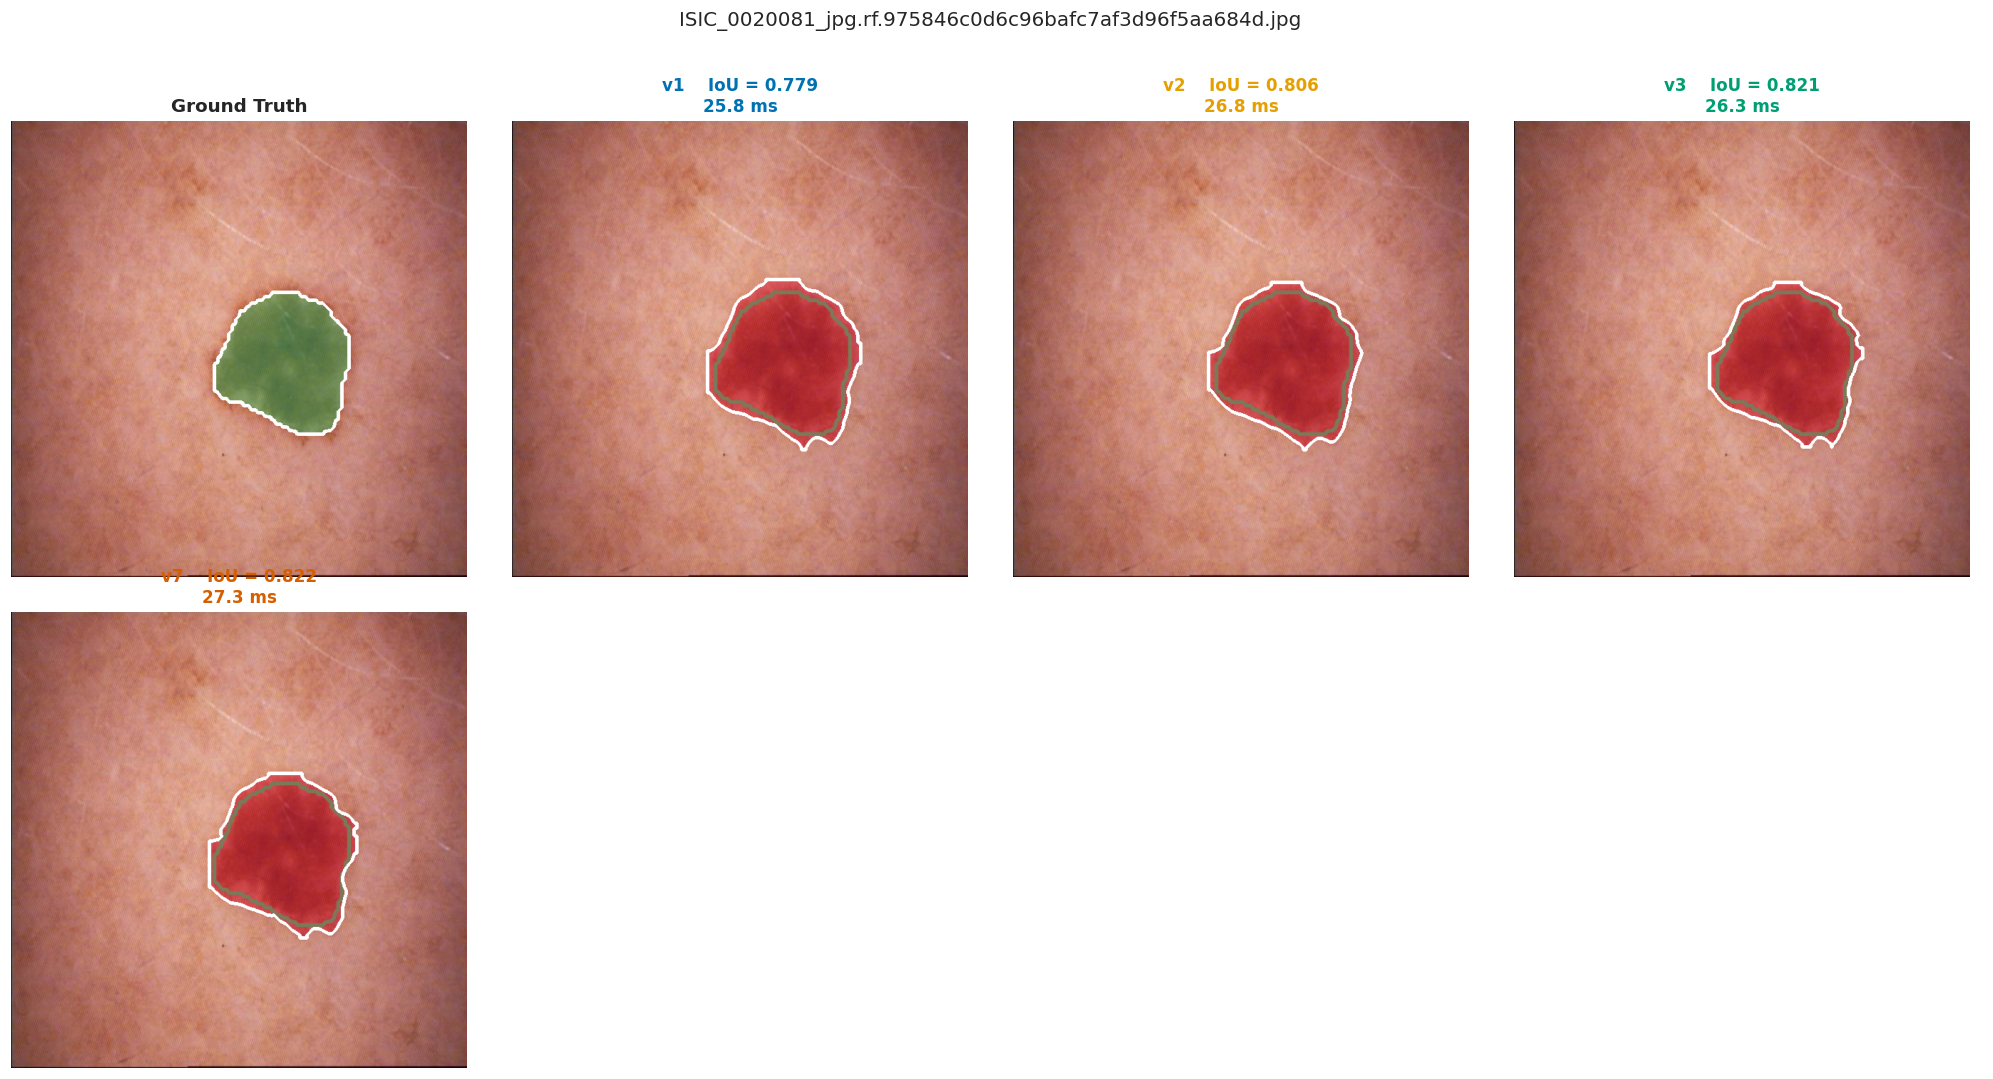

  saved → /home/antoniovinicius/projects/sandbox_yolo26/figures/qualitative/compare_versions_ISIC_0020081_jpg.rf.975846c0d6c96bafc7af3d96f5aa684d.png


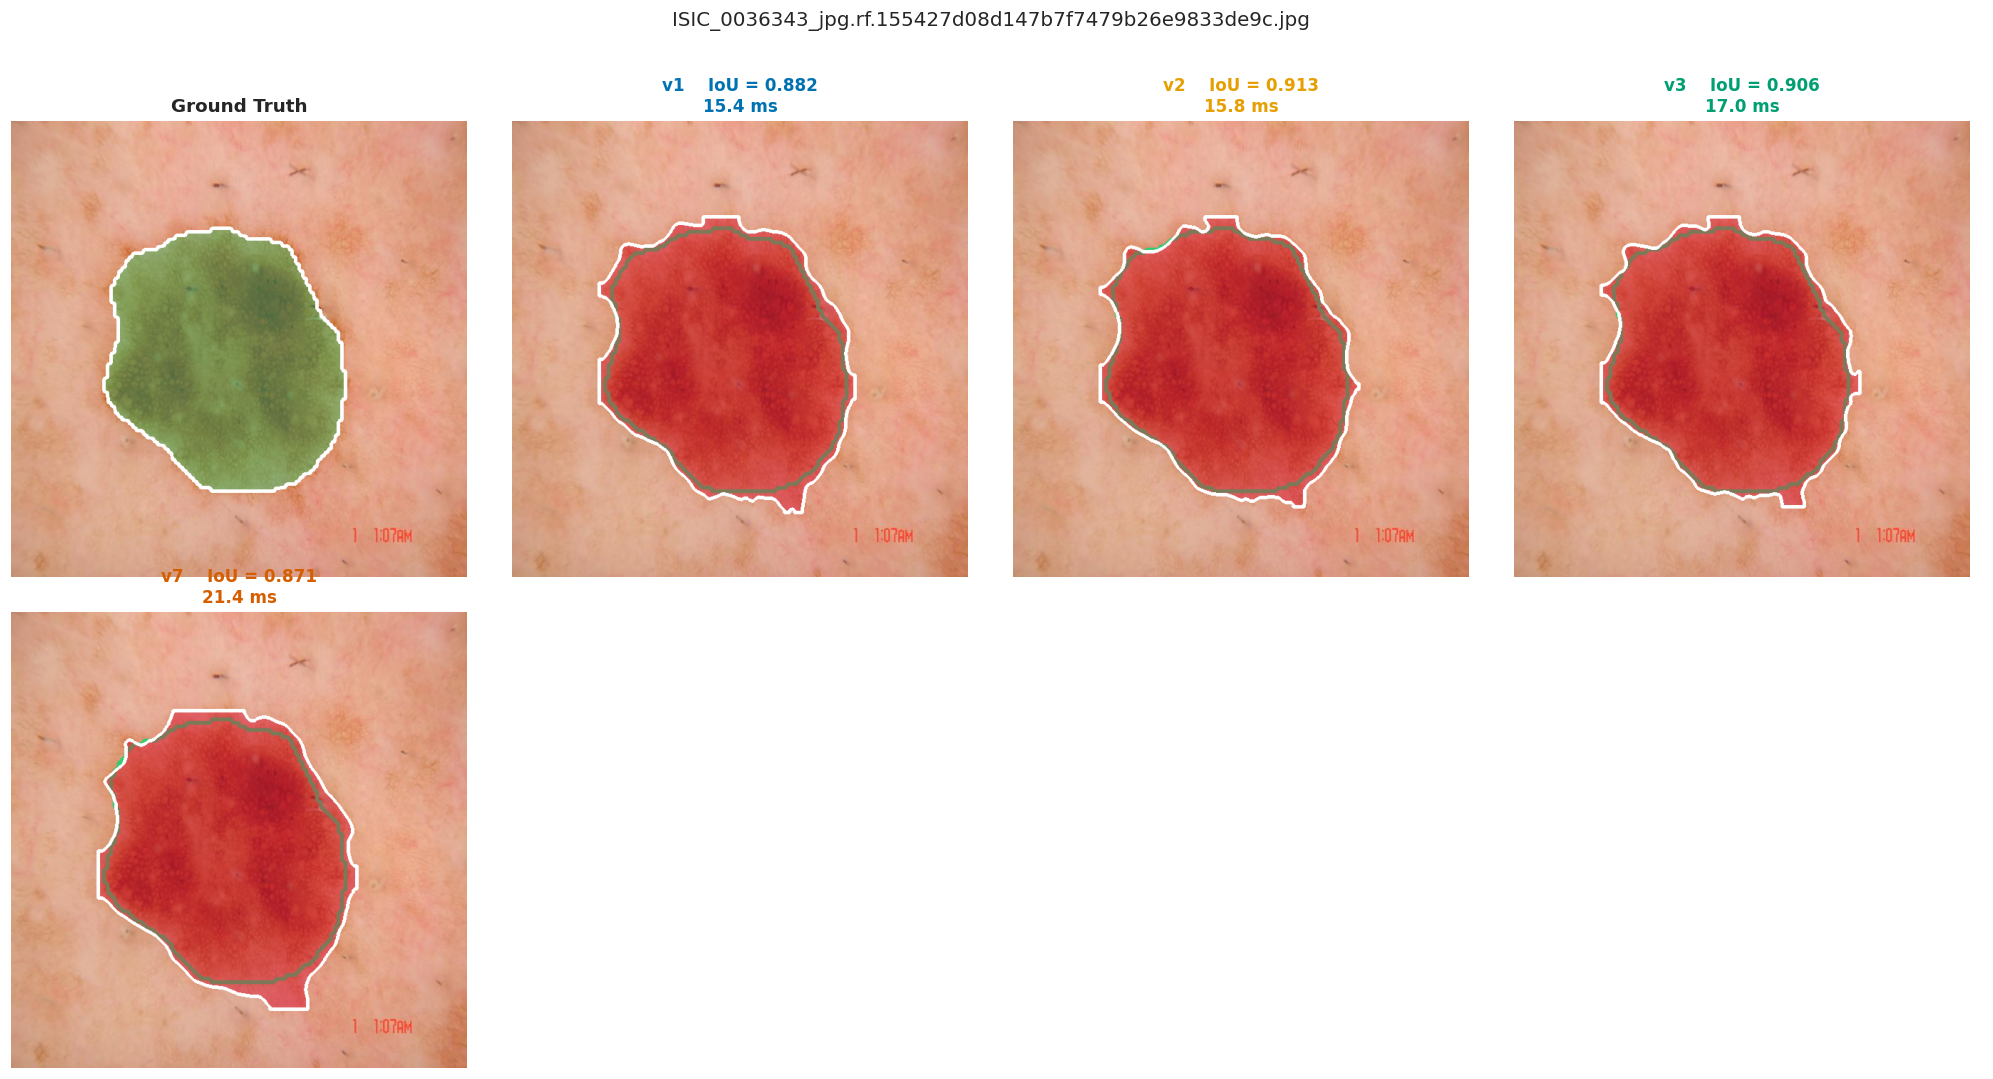

  saved → /home/antoniovinicius/projects/sandbox_yolo26/figures/qualitative/compare_versions_ISIC_0036343_jpg.rf.155427d08d147b7f7479b26e9833de9c.png


In [79]:
# Comparar versões usando o Small (default) — basta editar IMAGE_STEMS no
# bloco anterior para mudar quais imagens analisar.
compare_qualitative(
    image_stems=IMAGE_STEMS,
    axis_config=AXIS_CONFIG,
    axis_palette=AXIS_PALETTE,
    test_images_dir=TEST_IMAGES_DIR,
    test_labels_dir=TEST_LABELS_DIR,
    save_prefix="compare_versions",
)
